<a href="https://colab.research.google.com/github/DataSeerKeshav/DataSeerKeshav/blob/main/BA_AI_Python_DataScience_Tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Python & Data Science for Business Analytics and AI
### From core Python to Retrieval-Augmented Generation — one continuous supply-chain case

**Audience:** MSc Business Analytics & AI students
**Environment:** Google Colab (free tier). Parts 1–2 run on CPU. For Part 3, switch on a GPU: **Runtime → Change runtime type → T4 GPU**.

---

## The case: *NorthStar Logistics* (fictional)

NorthStar Logistics is a UK-based third-party logistics provider. It ships goods from three warehouses (Birmingham, Manchester, Felixstowe) to customers across the UK and Europe using several carriers and transport modes. Leadership has three questions, and each part of this notebook answers one:

| Part | Business question | Technique |
|---|---|---|
| 1 | *What does our shipment data look like, and where are the problems?* | Python, pandas, EDA, visualisation |
| 2 | *Can we predict what a shipment will cost, and whether it will arrive late?* | scikit-learn regression & classification |
| 3 | *Can staff ask plain-English questions of our logistics policy manual?* | LLMs, LangChain, RAG |

**How to use this notebook:** run cells top to bottom (`Shift + Enter`). Each code cell depends on the ones above it. If Colab disconnects, use **Runtime → Run before** to rebuild state.

## 0. Environment setup

Colab comes with `pandas`, `numpy`, `matplotlib`, `seaborn`, `scikit-learn`, `torch` and `transformers` pre-installed. We only need to add the Generative AI stack used in Part 3:

| Package | Role in Part 3 |
|---|---|
| `langchain`, `langchain-core` | The orchestration framework: prompts, chains, the "pipe" syntax |
| `langchain-community` | Community integrations — document loaders and the FAISS wrapper |
| `langchain-text-splitters` | Chunking long documents into pieces |
| `langchain-huggingface` | Connects LangChain to Hugging Face models (LLMs and embeddings) |
| `sentence-transformers` | Runs the embedding model that turns text into vectors |
| `faiss-cpu` | Facebook AI Similarity Search — our vector database |
| `chromadb`, `langchain-chroma` | An alternative vector database (shown as an optional swap) |

`-q` keeps the output quiet. If Colab shows a *"restart session"* prompt after installing, click it, then carry on from the next cell — the installed packages persist for the session.

In [1]:
# ---- Run once per Colab session (takes ~1-2 minutes) ----
!pip install -q -U langchain langchain-core langchain-community langchain-text-splitters langchain-huggingface
!pip install -q -U sentence-transformers faiss-cpu
!pip install -q chromadb langchain-chroma   # optional: only needed for the ChromaDB alternative in Part 3

import importlib.metadata as md
for pkg in ["pandas", "scikit-learn", "langchain", "langchain-huggingface", "sentence-transformers", "faiss-cpu", "transformers", "torch"]:
    try:
        print(f"{pkg:<24} {md.version(pkg)}")
    except md.PackageNotFoundError:
        print(f"{pkg:<24} NOT INSTALLED")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.7/164.7 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.1/572.1 kB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 46.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 35.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 4.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 740.6/740.6 kB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 67.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━

In [2]:
# Standard imports used throughout Parts 1 and 2
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid", context="notebook")

RANDOM_STATE = 42   # one seed everywhere = reproducible results for every student
print("Ready.")

Ready.


---
# PART 1 — The Basics & Data Wrangling
---
## 1.1 Core Python: variables and types

A **variable** in Python is a *name that points to an object in memory*. This is subtly different from languages like C, where a variable is a labelled box holding a value. In Python:

```python
x = 10
```
creates an integer object `10` somewhere in memory, and binds the name `x` to it. Every object carries three things: an **identity** (its memory address, see `id()`), a **type** (see `type()`), and a **value**.

Python is **dynamically typed**: types belong to *objects*, not names, so the same name can later point to a string. It is also **strongly typed**: it won't silently convert `"5" + 5` — you get an error, which protects you from subtle bugs in business data.

The core scalar types you will use constantly:

| Type | Example | Business use |
|---|---|---|
| `int` | `1200` | counts, units, IDs |
| `float` | `3.49` | prices, weights, costs |
| `str` | `"Felixstowe"` | categories, names |
| `bool` | `True` | flags (delayed? priority?) |
| `None` | `None` | "no value" — the Python cousin of a missing entry |

**Floating-point caveat:** floats are stored in binary, so `0.1 + 0.2` is *not exactly* `0.3`. For money in production systems, use `decimal.Decimal` or store pence as integers. For analytics, floats are fine — just never test floats with `==`.

In [3]:
# One shipment, described with basic variables
shipment_id   = "NS-000123"      # str
weight_kg     = 845.5            # float
n_pallets     = 3                # int
is_priority   = True             # bool
customs_ref   = None             # NoneType - not yet assigned

print(type(shipment_id), type(weight_kg), type(n_pallets), type(is_priority), type(customs_ref))

# f-strings: the modern way to format output. The :, and :.2f are format specifiers.
rate_per_kg = 0.42
print(f"Shipment {shipment_id}: {weight_kg:,.1f} kg x £{rate_per_kg} = £{weight_kg * rate_per_kg:,.2f}")

# Names point to objects: two names can point to the SAME object
a = [1, 2, 3]
b = a            # b is NOT a copy; it is a second label on the same list
b.append(4)
print("a =", a, "| same object?", a is b)

# Floating-point surprise
print("0.1 + 0.2 == 0.3 ?", 0.1 + 0.2 == 0.3, "->", 0.1 + 0.2)
print("Use np.isclose instead:", np.isclose(0.1 + 0.2, 0.3))

<class 'str'> <class 'float'> <class 'int'> <class 'bool'> <class 'NoneType'>
Shipment NS-000123: 845.5 kg x £0.42 = £355.11
a = [1, 2, 3, 4] | same object? True
0.1 + 0.2 == 0.3 ? False -> 0.30000000000000004
Use np.isclose instead: True


## 1.2 Core data structures

Python's four built-in collections are the foundation that `pandas` is built on. Choosing the right one is about **what operation you need to be fast**.

| Structure | Syntax | Ordered | Mutable | Duplicates | Under the hood | Fast at |
|---|---|---|---|---|---|---|
| **list** | `[a, b]` | ✓ | ✓ | ✓ | dynamic array of pointers | index access `x[i]`, appending |
| **tuple** | `(a, b)` | ✓ | ✗ | ✓ | fixed array | safe, hashable records |
| **dict** | `{k: v}` | ✓ (insertion) | ✓ | keys unique | **hash table** | lookup by key — O(1) |
| **set** | `{a, b}` | ✗ | ✓ | ✗ | hash table (keys only) | membership tests, de-duplication |

**Why hashing matters:** a `dict` computes `hash(key)` to jump straight to the memory slot where the value lives. So looking up `carrier_rates["DHL"]` takes the same time whether the dict has 10 entries or 10 million. Searching a *list* for a value (`"DHL" in my_list`) must scan every element — O(n). On large business datasets, that difference is minutes versus milliseconds.

**Mutability matters:** tuples cannot be changed after creation, which makes them *hashable* — they can be dictionary keys (e.g. a `(origin, destination)` lane). Lists cannot.

In [4]:
# LIST - ordered collection of warehouses
warehouses = ["Birmingham", "Manchester", "Felixstowe"]
warehouses.append("Glasgow")                 # mutate in place
print("Warehouses:", warehouses, "| first:", warehouses[0], "| last:", warehouses[-1])
print("Slice [1:3]:", warehouses[1:3])       # start inclusive, stop exclusive

# TUPLE - an immutable record; perfect as a dictionary key for a shipping lane
lane = ("Felixstowe", "Rotterdam")

# DICT - carrier rate card (£ per kg); O(1) lookup by key
carrier_rates = {"DHL": 0.55, "DPD": 0.42, "Royal Mail": 0.38, "Maersk": 0.21}
print("DPD rate:", carrier_rates["DPD"])
print("FedEx rate (safe lookup):", carrier_rates.get("FedEx", "not on rate card"))

# Tuple keys - lane-level transit times in days
lane_transit_days = {("Felixstowe", "Rotterdam"): 2, ("Birmingham", "London"): 1}
print("Transit on", lane, "=", lane_transit_days[lane], "days")

# SET - unique carriers used this week (duplicates vanish automatically)
carriers_used = {"DHL", "DPD", "DHL", "Maersk", "DPD"}
approved = {"DHL", "DPD", "Royal Mail"}
print("Unique carriers used:", carriers_used)
print("Used but NOT approved (set difference):", carriers_used - approved)

# Nested structures: a list of dicts is exactly how JSON / API data usually arrives
shipments = [
    {"id": "NS-1", "carrier": "DHL",    "weight_kg": 120, "delayed": False},
    {"id": "NS-2", "carrier": "DPD",    "weight_kg": 540, "delayed": True},
    {"id": "NS-3", "carrier": "Maersk", "weight_kg": 2300, "delayed": False},
]
print("Second shipment carrier:", shipments[1]["carrier"])

Warehouses: ['Birmingham', 'Manchester', 'Felixstowe', 'Glasgow'] | first: Birmingham | last: Glasgow
Slice [1:3]: ['Manchester', 'Felixstowe']
DPD rate: 0.42
FedEx rate (safe lookup): not on rate card
Transit on ('Felixstowe', 'Rotterdam') = 2 days
Unique carriers used: {'Maersk', 'DPD', 'DHL'}
Used but NOT approved (set difference): {'Maersk'}
Second shipment carrier: DPD


## 1.3 Control flow: conditions and loops

- `if / elif / else` evaluates conditions top to bottom and runs **only the first** true branch.
- A `for` loop in Python iterates over **any iterable** (list, dict, string, file, DataFrame rows…). Under the hood, `for x in obj` calls `iter(obj)` to get an *iterator*, then repeatedly calls `next()` on it until a `StopIteration` signal ends the loop. That's why you can loop over so many different things with one syntax.
- `enumerate()` gives you a counter alongside each item; `zip()` walks several iterables in lockstep; `.items()` gives key–value pairs from a dict.
- A **list comprehension** `[f(x) for x in items if condition]` is a compact loop that builds a list. It's idiomatic and usually faster than an equivalent `for` + `append`.

> **Performance note you'll revisit in pandas:** Python loops execute one element at a time in the interpreter. For large data we use *vectorised* numpy/pandas operations, which push the loop down into compiled C code. Learn loops for logic; use vectorisation for volume.

In [5]:
# Classify shipments by weight band and compute cost
total_cost = 0.0
for i, s in enumerate(shipments, start=1):
    w = s["weight_kg"]
    if w < 200:
        band = "Parcel"
    elif w < 1000:
        band = "Pallet"
    else:
        band = "Freight"

    cost = w * carrier_rates[s["carrier"]]
    total_cost += cost
    flag = "LATE" if s["delayed"] else "on time"     # conditional expression
    print(f"{i}. {s['id']:<5} {band:<8} {s['carrier']:<7} £{cost:>8,.2f}  ({flag})")

print(f"Total spend: £{total_cost:,.2f}")

# Iterating over a dict
for carrier, rate in carrier_rates.items():
    print(f"  {carrier:<11} £{rate:.2f}/kg")

# List comprehension: IDs of delayed shipments
delayed_ids = [s["id"] for s in shipments if s["delayed"]]
print("Delayed:", delayed_ids)

# Dict comprehension: apply a 5% fuel surcharge to every carrier rate
surcharged = {c: round(r * 1.05, 3) for c, r in carrier_rates.items()}
print("With surcharge:", surcharged)

# zip: pair two parallel lists
for wh, cap in zip(["Birmingham", "Manchester", "Felixstowe"], [12000, 8000, 20000]):
    print(f"{wh} capacity: {cap:,} pallets")

# while loop: how many weeks until backlog clears?
backlog, weekly_capacity, weeks = 5000, 1300, 0
while backlog > 0:
    backlog -= weekly_capacity
    weeks += 1
print(f"Backlog clears in {weeks} weeks")

1. NS-1  Parcel   DHL     £   66.00  (on time)
2. NS-2  Pallet   DPD     £  226.80  (LATE)
3. NS-3  Freight  Maersk  £  483.00  (on time)
Total spend: £775.80
  DHL         £0.55/kg
  DPD         £0.42/kg
  Royal Mail  £0.38/kg
  Maersk      £0.21/kg
Delayed: ['NS-2']
With surcharge: {'DHL': 0.578, 'DPD': 0.441, 'Royal Mail': 0.399, 'Maersk': 0.221}
Birmingham capacity: 12,000 pallets
Manchester capacity: 8,000 pallets
Felixstowe capacity: 20,000 pallets
Backlog clears in 4 weeks


## 1.4 Defining functions

A **function** packages logic so it can be reused, tested and documented. Key ideas:

- **Parameters & arguments:** positional (`f(1, 2)`), keyword (`f(weight=1)`), and **defaults** (`def f(x, rate=0.4)`).
- **Return values:** `return` sends a result back; a function with no `return` returns `None`.
- **Scope (LEGB rule):** Python looks up a name in the **L**ocal function scope, then **E**nclosing functions, then **G**lobal (module) scope, then **B**uilt-ins. Variables created inside a function vanish when it finishes.
- **Docstrings & type hints:** `def f(x: float) -> float:` documents intent. Hints are *not* enforced at runtime, but IDEs and linters use them.
- **Functions are objects:** you can pass them to other functions — that's how `pandas.apply()`, `sorted(key=...)` and scikit-learn pipelines work.

⚠️ **Classic trap:** never use a mutable default like `def f(items=[])`. The default list is created **once** when the function is defined and shared across every call. Use `items=None` and create the list inside.

In [6]:
def shipping_cost(weight_kg: float, carrier: str, distance_km: float = 100.0,
                  priority: bool = False, rates: dict = None) -> float:
    '''
    Estimate the cost of a shipment in GBP.

    cost = weight x carrier rate x distance factor, plus a 25% priority uplift.
    Raises ValueError if the carrier is unknown.
    '''
    rates = rates if rates is not None else carrier_rates   # safe default pattern
    if carrier not in rates:
        raise ValueError(f"Unknown carrier: {carrier!r}")
    distance_factor = 1 + distance_km / 1000          # longer trips cost more
    cost = weight_kg * rates[carrier] * distance_factor
    if priority:
        cost *= 1.25
    return round(cost, 2)

print(shipping_cost(500, "DPD"))                                   # defaults used
print(shipping_cost(500, "DPD", distance_km=450, priority=True))   # keyword arguments

try:
    shipping_cost(500, "FedEx")
except ValueError as e:
    print("Caught error ->", e)

# Functions as arguments: sort shipments by a computed cost
ranked = sorted(shipments, key=lambda s: shipping_cost(s["weight_kg"], s["carrier"]), reverse=True)
print("Most expensive first:", [s["id"] for s in ranked])

# Returning multiple values = returning a tuple, then unpacking it
def summarise(values):
    return min(values), max(values), sum(values) / len(values)

lo, hi, avg = summarise([s["weight_kg"] for s in shipments])
print(f"Weights - min {lo}, max {hi}, mean {avg:,.1f}")

231.0
380.62
Caught error -> Unknown carrier: 'FedEx'
Most expensive first: ['NS-3', 'NS-2', 'NS-1']
Weights - min 120, max 2300, mean 986.7


## 1.5 Data import & handling with pandas

### What *is* a DataFrame, really?

A `pandas.DataFrame` is a 2-D table where:
- each **column** is a `Series` — a 1-D **numpy array** of a single `dtype` (e.g. `float64`, `int64`, `object`/`string`, `category`, `datetime64`);
- every row and column is labelled by an **Index**, which makes alignment and lookups by label fast.

Because each column is a contiguous typed array, operations like `df["cost"] * 1.2` run in compiled C across the whole column at once — **vectorisation**. That's why pandas is fast, and why a Python `for` loop over rows (`iterrows`) is 100× slower and should be a last resort.

### Generating our dataset

Real company data is confidential, so we'll **simulate** NorthStar's shipment log. Simulating also has teaching value: because *we* write the rules that generate cost and delay, we'll know later whether our models discovered the true drivers. We deliberately inject messiness — missing values, a dirty category label, and a couple of data-entry errors — because real data always has them.

In practice you'd load a file instead:
```python
df = pd.read_csv("shipments.csv")                         # from Colab's file panel
df = pd.read_excel("shipments.xlsx", sheet_name="2025")    # Excel
# from Google Drive:
from google.colab import drive; drive.mount('/content/drive')
df = pd.read_csv("/content/drive/MyDrive/data/shipments.csv")
```

In [7]:
def generate_shipments(n: int = 3000, seed: int = RANDOM_STATE) -> pd.DataFrame:
    '''Simulate NorthStar Logistics shipment records with realistic noise and messiness.'''
    rng = np.random.default_rng(seed)

    origin   = rng.choice(["Birmingham", "Manchester", "Felixstowe"], n, p=[0.40, 0.25, 0.35])
    region   = rng.choice(["London", "South East", "North", "Scotland", "EU-Benelux", "EU-Germany"],
                          n, p=[0.25, 0.20, 0.20, 0.10, 0.15, 0.10])
    carrier  = rng.choice(["DHL", "DPD", "Royal Mail", "Maersk"], n, p=[0.30, 0.35, 0.20, 0.15])
    mode     = np.where(np.isin(region, ["EU-Benelux", "EU-Germany"]),
                        rng.choice(["Road", "Sea"], n, p=[0.6, 0.4]),
                        rng.choice(["Road", "Rail"], n, p=[0.85, 0.15]))
    base_km  = pd.Series(region).map({"London": 180, "South East": 220, "North": 250,
                                      "Scotland": 520, "EU-Benelux": 650, "EU-Germany": 900}).to_numpy()
    distance = np.clip(base_km + rng.normal(0, 60, n), 20, None).round(0)
    weight   = np.round(rng.lognormal(mean=5.5, sigma=1.0, size=n), 1)       # right-skewed, like real freight
    items    = np.maximum(1, (weight / rng.uniform(15, 60, n)).astype(int))
    priority = rng.random(n) < 0.18
    weather  = rng.choice(["Clear", "Rain", "Storm"], n, p=[0.65, 0.28, 0.07])
    dates    = pd.Timestamp("2025-01-01") + pd.to_timedelta(rng.integers(0, 365, n), unit="D")
    fuel     = np.round(1.45 + 0.12 * np.sin(2 * np.pi * dates.dayofyear / 365) + rng.normal(0, 0.03, n), 3)

    rate  = pd.Series(carrier).map({"DHL": 0.55, "DPD": 0.42, "Royal Mail": 0.38, "Maersk": 0.21}).to_numpy()
    mode_mult = pd.Series(mode).map({"Road": 1.0, "Rail": 0.8, "Sea": 0.6}).to_numpy()
    cost = (25 + weight * rate * mode_mult * (1 + distance / 800) * (fuel / 1.45)
            * np.where(priority, 1.3, 1.0) + rng.normal(0, 20, n))
    cost = np.round(np.clip(cost, 15, None), 2)

    planned = np.ceil(distance / 300 + np.where(mode == "Sea", 3, 0) - np.where(priority, 1, 0)).clip(1)
    logit = (-2.4 + 0.0012 * distance + np.where(weather == "Rain", 0.6, 0) + np.where(weather == "Storm", 1.8, 0)
             + pd.Series(carrier).map({"DHL": -0.3, "DPD": 0.2, "Royal Mail": 0.5, "Maersk": 0.1}).to_numpy()
             + np.where(dates.month.isin([11, 12]), 0.7, 0)     # peak season congestion
             - np.where(priority, 0.5, 0) + 0.00015 * weight)
    delayed = (rng.random(n) < 1 / (1 + np.exp(-logit))).astype(int)

    df = pd.DataFrame({
        "shipment_id": [f"NS-{i:06d}" for i in range(1, n + 1)],
        "order_date": dates, "origin_warehouse": origin, "destination_region": region,
        "carrier": carrier, "transport_mode": mode, "distance_km": distance, "weight_kg": weight,
        "n_items": items, "priority": priority, "weather": weather, "fuel_price_gbp_l": fuel,
        "planned_days": planned.astype(int), "cost_gbp": cost, "delayed": delayed,
    })

    # ---- inject real-world messiness ----
    df.loc[rng.choice(n, 120, replace=False), "weight_kg"] = np.nan
    df.loc[rng.choice(n, 90, replace=False), "weather"] = np.nan
    df.loc[rng.choice(n, 60, replace=False), "fuel_price_gbp_l"] = np.nan
    df.loc[rng.choice(n, 40, replace=False), "carrier"] = "dhl "         # inconsistent label
    df.loc[rng.choice(n, 3, replace=False), "distance_km"] = -1          # impossible values (entry errors)
    return df

raw = generate_shipments()
raw.to_csv("northstar_shipments.csv", index=False)     # save, so we can practise loading a real file
df = pd.read_csv("northstar_shipments.csv", parse_dates=["order_date"])
print(df.shape)
df.head()

(3000, 15)


,shipment_id,order_date,origin_warehouse,destination_region,carrier,transport_mode,distance_km,weight_kg,n_items,priority,weather,fuel_price_gbp_l,planned_days,cost_gbp,delayed
0,NS-000001,2025-07-14,Felixstowe,EU-Benelux,DPD,Sea,736.00,868.50,27,False,Clear,1.46,6,446.28,0
1,NS-000002,2025-08-09,Manchester,North,DHL,Road,356.00,324.10,7,False,Storm,1.34,2,246.54,0
2,NS-000003,2025-02-03,Felixstowe,London,DPD,Road,200.00,357.80,23,False,Clear,1.52,1,206.48,0
3,NS-000004,2025-07-14,Felixstowe,Scotland,DHL,Rail,446.00,57.80,1,False,Clear,1.39,2,46.21,0
4,NS-000005,2025-02-01,Birmingham,London,DHL,Road,286.00,260.20,4,True,Rain,1.54,1,308.60,0


### First look: structure before statistics

Always start with these four calls. They answer: *How big is it? What types did pandas infer? Is anything missing? What do values look like?*

- `df.info()` — column names, non-null counts, dtypes, memory use. A column of numbers showing dtype `object` usually means a stray text value snuck in.
- `df.dtypes` — just the types.
- `df.sample()` — random rows (better than `head()`, which may show a sorted or unrepresentative block).
- `df.nunique()` — cardinality: how many distinct values each column has. Low cardinality text → a categorical variable.

In [8]:
df.info()
print("\nDistinct values per column:\n", df.nunique())
df.sample(5, random_state=RANDOM_STATE)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   shipment_id         3000 non-null   object        
 1   order_date          3000 non-null   datetime64[ns]
 2   origin_warehouse    3000 non-null   object        
 3   destination_region  3000 non-null   object        
 4   carrier             3000 non-null   object        
 5   transport_mode      3000 non-null   object        
 6   distance_km         3000 non-null   float64       
 7   weight_kg           2880 non-null   float64       
 8   n_items             3000 non-null   int64         
 9   priority            3000 non-null   bool          
 10  weather             2910 non-null   object        
 11  fuel_price_gbp_l    2940 non-null   float64       
 12  planned_days        3000 non-null   int64         
 13  cost_gbp            3000 non-null   float64     

,shipment_id,order_date,origin_warehouse,destination_region,carrier,transport_mode,distance_km,weight_kg,n_items,priority,weather,fuel_price_gbp_l,planned_days,cost_gbp,delayed
1801,NS-001802,2025-06-24,Manchester,London,Royal Mail,Road,205.00,198.40,4,True,Rain,1.52,1,155.85,0
1190,NS-001191,2025-06-15,Manchester,London,DPD,Road,208.00,NaN,6,False,Rain,1.47,1,112.54,1
1817,NS-001818,2025-06-30,Manchester,North,Royal Mail,Road,216.00,NaN,16,False,Rain,1.46,1,278.32,0
251,NS-000252,2025-04-19,Felixstowe,North,DHL,Road,403.00,86.40,1,False,Clear,1.54,2,100.66,0
2505,NS-002506,2025-05-22,Birmingham,South East,DHL,Road,194.00,114.60,2,False,Storm,1.54,1,162.82,0


### Selecting, filtering and creating columns

| Task | Syntax | Notes |
|---|---|---|
| One column | `df["cost_gbp"]` | returns a **Series** |
| Several columns | `df[["carrier", "cost_gbp"]]` | double brackets → **DataFrame** |
| Rows by **label** | `df.loc[row_labels, col_labels]` | label-based, **inclusive** slice end |
| Rows by **position** | `df.iloc[0:5, 0:3]` | integer-based, exclusive end |
| Filter | `df[df["cost_gbp"] > 500]` | a **boolean mask** — a Series of True/False aligned by index |
| Combine conditions | `(a) & (b)`, `(a) \| (b)`, `~a` | use `&`/`\|`/`~`, **not** `and`/`or`, and wrap each condition in brackets |
| Readable filter | `df.query("cost_gbp > 500 and priority")` | same result, SQL-like |

**Under the hood of a filter:** `df["cost_gbp"] > 500` builds a boolean array in one vectorised pass. Passing it back into `df[...]` keeps rows where the mask is `True`. Nothing is looped in Python.

**Assignment rule:** to modify a subset, use `.loc` in one step — `df.loc[mask, "col"] = value`. Chained indexing like `df[mask]["col"] = value` may modify a temporary copy and silently do nothing (the famous `SettingWithCopyWarning`).

In [9]:
# Selection
print(df[["shipment_id", "carrier", "cost_gbp"]].head(3), "\n")
print(df.loc[0:2, "origin_warehouse":"carrier"], "\n")   # label slice - end INCLUSIVE
print(df.iloc[0:2, 0:3], "\n")                            # position slice - end EXCLUSIVE

# Boolean filtering: expensive, late, priority shipments
mask = (df["cost_gbp"] > 500) & (df["delayed"] == 1) & (df["priority"])
print(f"{mask.sum()} expensive, late priority shipments")
print(df.query("destination_region == 'Scotland' and weather == 'Storm'").shape[0], "Scottish storm shipments")

# New columns - vectorised arithmetic, no loops
df["cost_per_kg"]  = df["cost_gbp"] / df["weight_kg"]
df["order_month"]  = df["order_date"].dt.month            # .dt accessor for datetimes
df["is_peak"]      = df["order_month"].isin([11, 12]).astype(int)
df["is_eu"]        = df["destination_region"].str.startswith("EU").astype(int)   # .str accessor for text

# Conditional column with np.select (vectorised if/elif/else)
df["weight_band"] = np.select(
    [df["weight_kg"] < 200, df["weight_kg"] < 1000, df["weight_kg"] >= 1000],
    ["Parcel", "Pallet", "Freight"], default="Unknown")
df[["weight_kg", "weight_band", "cost_per_kg", "order_month", "is_peak", "is_eu"]].head()

  shipment_id carrier  cost_gbp
0   NS-000001     DPD    446.28
1   NS-000002     DHL    246.54
2   NS-000003     DPD    206.48 

  origin_warehouse destination_region carrier
0       Felixstowe         EU-Benelux     DPD
1       Manchester              North     DHL
2       Felixstowe             London     DPD 

  shipment_id order_date origin_warehouse
0   NS-000001 2025-07-14       Felixstowe
1   NS-000002 2025-08-09       Manchester 

14 expensive, late priority shipments
23 Scottish storm shipments


,weight_kg,weight_band,cost_per_kg,order_month,is_peak,is_eu
0,868.50,Pallet,0.51,7,0,1
1,324.10,Pallet,0.76,8,0,0
2,357.80,Pallet,0.58,2,0,0
3,57.80,Parcel,0.80,7,0,0
4,260.20,Pallet,1.19,2,0,0


### Grouping, aggregating and reshaping — "split–apply–combine"

`groupby` is the most important business-analytics operation in pandas. It works in three steps:

1. **Split** the rows into groups by one or more keys (e.g. carrier);
2. **Apply** a function to each group (sum, mean, count, custom);
3. **Combine** the results into a new table.

It's the pandas equivalent of SQL's `GROUP BY`. Named aggregation — `agg(new_name=("column", "func"))` — keeps output tidy. `pivot_table` reshapes the result into a matrix (rows × columns), like an Excel pivot table. `merge` joins two tables on a key, exactly like SQL `JOIN`.

In [10]:
# Carrier scorecard (note: 'dhl ' dirty label shows up as its own group - we'll fix that in cleaning)
scorecard = (df.groupby("carrier")
               .agg(shipments=("shipment_id", "count"),
                    total_spend=("cost_gbp", "sum"),
                    avg_cost=("cost_gbp", "mean"),
                    delay_rate=("delayed", "mean"))
               .sort_values("total_spend", ascending=False))
print(scorecard, "\n")

# Pivot: delay rate by region x transport mode
pivot = df.pivot_table(index="destination_region", columns="transport_mode",
                       values="delayed", aggfunc="mean").round(3)
print(pivot, "\n")

# Merge: bring in a carrier contract table (a second 'dimension' table)
contracts = pd.DataFrame({"carrier": ["DHL", "DPD", "Royal Mail", "Maersk"],
                          "contract_tier": ["Gold", "Silver", "Silver", "Bronze"],
                          "sla_on_time_target": [0.90, 0.85, 0.85, 0.80]})
merged = df.merge(contracts, on="carrier", how="left")   # left join keeps every shipment
print("Rows with no contract match (the dirty 'dhl ' label):", merged["contract_tier"].isna().sum())

            shipments  total_spend  avg_cost  delay_rate
carrier                                                 
DHL               877   311,866.29    355.61        0.14
DPD              1045   310,584.16    297.21        0.20
Royal Mail        595   156,644.75    263.27        0.29
Maersk            443    64,205.45    144.93        0.21
dhl                40    11,916.46    297.91        0.15 

transport_mode      Rail  Road  Sea
destination_region                 
EU-Benelux           NaN  0.25 0.26
EU-Germany           NaN  0.35 0.31
London              0.14  0.16  NaN
North               0.17  0.17  NaN
Scotland            0.20  0.23  NaN
South East          0.18  0.19  NaN 

Rows with no contract match (the dirty 'dhl ' label): 40


## 1.6 Exploratory Data Analysis (EDA)

### Step 1 — Data quality: fix the obvious problems first

We already spotted two issues: an inconsistent carrier label (`"dhl "`) and impossible negative distances. Cleaning categorical text is almost always the first job — otherwise every group-by and model treats `"DHL"` and `"dhl "` as different carriers.

Invalid numeric values (a distance of −1 km) should not be kept as-is. We convert them to `NaN` (missing), so they flow into the same missing-value strategy as other gaps rather than being silently averaged in.

In [11]:
print("Before:", sorted(df["carrier"].unique()))
df["carrier"] = df["carrier"].str.strip().str.upper().replace({"ROYAL MAIL": "Royal Mail", "MAERSK": "Maersk"})
print("After: ", sorted(df["carrier"].unique()))

bad = df["distance_km"] <= 0
print(f"Invalid distances found: {bad.sum()} -> set to NaN")
df.loc[bad, "distance_km"] = np.nan

# Duplicates check - always worth one line
print("Duplicate shipment IDs:", df["shipment_id"].duplicated().sum())

Before: ['DHL', 'DPD', 'Maersk', 'Royal Mail', 'dhl ']
After:  ['DHL', 'DPD', 'Maersk', 'Royal Mail']
Invalid distances found: 3 -> set to NaN
Duplicate shipment IDs: 0


### Step 2 — Descriptive statistics

`df.describe()` gives for each numeric column: **count** (non-missing), **mean**, **std** (spread), **min**, **quartiles** (25%, 50% = median, 75%), **max**.

How to read it like an analyst:
- **Mean vs median:** if the mean is well above the median, the distribution is **right-skewed** — a few very large values pull the mean up. Freight weights and costs are classic examples. For skewed data, the median is the better "typical" value.
- **Std relative to mean** (coefficient of variation) tells you how variable the column is.
- **Min/max** reveal impossible values and outliers.
- **Skewness** > 1 means strongly right-skewed; ≈ 0 is symmetric.

For categorical columns, `describe(include="object")` gives count, number of unique values, the most frequent value (`top`) and its frequency.

In [12]:
num_cols = ["distance_km", "weight_kg", "n_items", "fuel_price_gbp_l", "planned_days", "cost_gbp"]
desc = df[num_cols].describe().T
desc["median"] = df[num_cols].median()
desc["skew"] = df[num_cols].skew()
print(desc[["count", "mean", "median", "std", "min", "max", "skew"]], "\n")

print(df[["origin_warehouse", "destination_region", "carrier", "transport_mode", "weather"]]
      .describe(include="object").T, "\n")

print(f"Overall delay rate: {df['delayed'].mean():.1%}")
print(df["carrier"].value_counts(normalize=True).rename("share").round(3))

                    count   mean  median    std   min      max  skew
distance_km      2,997.00 372.90  263.00 245.20 20.00 1,059.00  0.96
weight_kg        2,880.00 423.98  259.45 511.47  6.00 5,477.40  3.49
n_items          3,000.00  12.56    7.00  17.79  1.00   208.00  4.38
fuel_price_gbp_l 2,940.00   1.45    1.45   0.09  1.23     1.68  0.03
planned_days     3,000.00   1.89    1.00   1.51  1.00     7.00  1.89
cost_gbp         3,000.00 285.07  169.92 364.89 15.00 4,501.19  4.39 

                   count unique         top  freq
origin_warehouse    3000      3  Birmingham  1195
destination_region  3000      6      London   776
carrier             3000      4         DPD  1045
transport_mode      3000      3        Road  2375
weather             2910      3       Clear  1890 

Overall delay rate: 20.3%
carrier
DPD          0.35
DHL          0.31
Royal Mail   0.20
Maersk       0.15
Name: share, dtype: float64


### Step 3 — Handling missing values

First, **measure** the gaps. Then decide *why* data is missing, because that determines the fix:

| Mechanism | Meaning | Example | Consequence |
|---|---|---|---|
| **MCAR** — missing completely at random | Missingness unrelated to anything | a scanner randomly failed | Dropping rows is unbiased (just loses data) |
| **MAR** — missing at random | Related to *other observed* columns | weight missing more often for Rail shipments | Impute using those other columns |
| **MNAR** — missing not at random | Related to the *missing value itself* | very heavy loads not weighed because the scale maxes out | Hardest; needs domain knowledge; imputation can mislead |

Common strategies:
- **Drop** rows (`dropna`) — fine when few rows are affected *and* data is MCAR.
- **Impute** with median (numeric, robust to skew), mode (categorical), or a **group-wise** median (e.g. median weight *per weight band or carrier*), which respects structure in the data.
- **Flag it:** add an `is_missing` indicator column, so a model can learn if missingness itself is informative.

⚠️ **Crucial for Part 2:** imputation values (like a median) must be learned from **training data only**. Here we explore; in Part 2 we'll do it properly inside a scikit-learn pipeline to avoid *data leakage*.

                  n_missing  pct
weight_kg               120 4.00
cost_per_kg             120 4.00
weather                  90 3.00
fuel_price_gbp_l         60 2.00
distance_km               3 0.10 



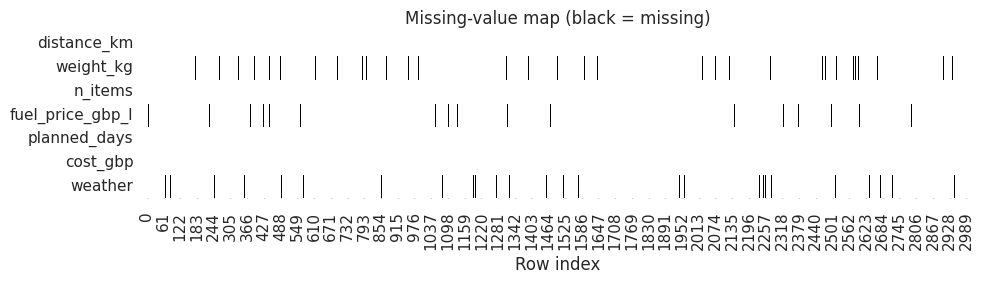

Remaining missing values: 0


In [13]:
missing = pd.DataFrame({"n_missing": df.isna().sum(), "pct": df.isna().mean() * 100})
missing = missing[missing["n_missing"] > 0].sort_values("pct", ascending=False)
print(missing, "\n")

fig, ax = plt.subplots(figsize=(10, 3))
sns.heatmap(df[num_cols + ["weather"]].isna().T, cbar=False, cmap="Greys", ax=ax)
ax.set_title("Missing-value map (black = missing)"); ax.set_xlabel("Row index")
plt.tight_layout(); plt.show()

# Exploratory imputation on a copy (Part 2 redoes this leak-free inside a pipeline)
eda = df.copy()
eda["weight_missing"] = eda["weight_kg"].isna().astype(int)                                  # flag
eda["weight_kg"] = eda["weight_kg"].fillna(eda.groupby("carrier")["weight_kg"].transform("median"))  # group median
eda["distance_km"] = eda["distance_km"].fillna(eda.groupby("destination_region")["distance_km"].transform("median"))
eda["fuel_price_gbp_l"] = eda["fuel_price_gbp_l"].fillna(eda["fuel_price_gbp_l"].median())
eda["weather"] = eda["weather"].fillna(eda["weather"].mode()[0])                              # mode for categories
eda["cost_per_kg"] = eda["cost_gbp"] / eda["weight_kg"]
print("Remaining missing values:", eda[num_cols + ["weather"]].isna().sum().sum())

### Step 4 — Visualisation

**`matplotlib`** is the low-level engine: a **Figure** is the whole canvas; it contains one or more **Axes** (individual plots). The pattern `fig, axes = plt.subplots(rows, cols)` gives you full control. **`seaborn`** sits on top of matplotlib, understands DataFrames, and computes statistical summaries (means, confidence intervals, KDEs) for you. Every seaborn plot accepts `ax=` so you can place it on a matplotlib grid.

Pick the chart by the question:

| Question | Chart |
|---|---|
| How is one numeric variable distributed? | **Histogram** (+ KDE) |
| How do two numeric variables relate? | **Scatter plot** |
| How does a numeric variable differ across categories? | Box plot / bar plot |
| Which variables move together? | **Correlation heatmap** |

**Histogram mechanics:** the value range is cut into *bins*, and bar height = count of observations in each bin. Too few bins hides shape; too many creates noise. A **KDE** (kernel density estimate) smooths the histogram by placing a small bell curve on every data point and summing them.

**Log scale:** for right-skewed data (weights, costs), plotting `log(x)` spreads the dense low values and compresses the long tail, often revealing a near-normal shape — a hint that a log transformation may help linear models.

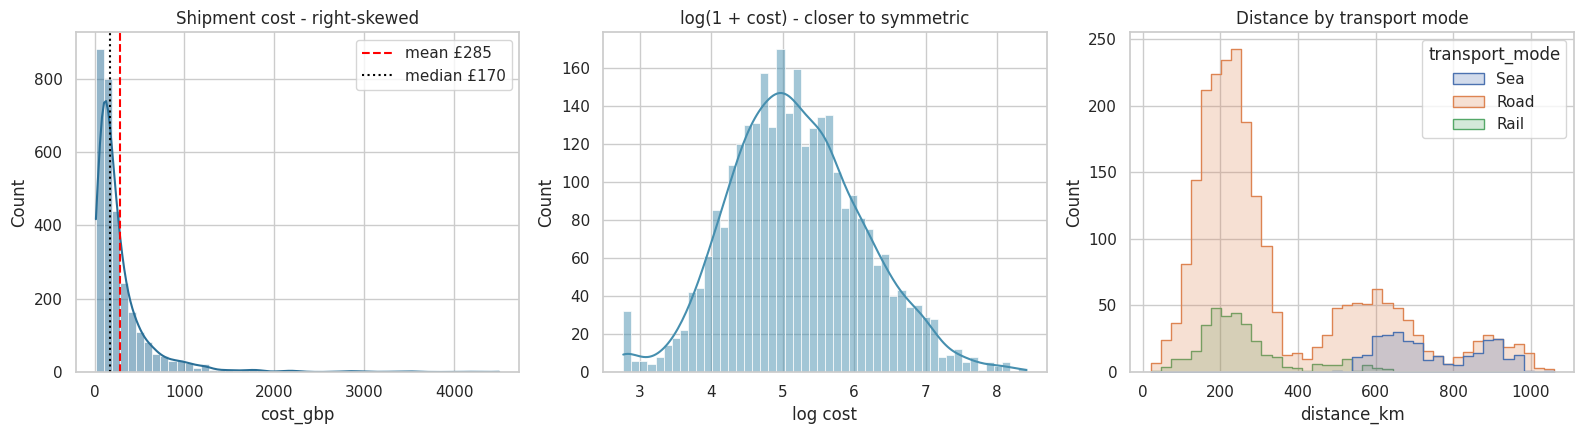

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

sns.histplot(eda["cost_gbp"], bins=50, kde=True, ax=axes[0], color="#2a6f97")
axes[0].axvline(eda["cost_gbp"].mean(), color="red", ls="--", label=f"mean £{eda['cost_gbp'].mean():,.0f}")
axes[0].axvline(eda["cost_gbp"].median(), color="black", ls=":", label=f"median £{eda['cost_gbp'].median():,.0f}")
axes[0].set_title("Shipment cost - right-skewed"); axes[0].legend()

sns.histplot(np.log1p(eda["cost_gbp"]), bins=50, kde=True, ax=axes[1], color="#468faf")
axes[1].set_title("log(1 + cost) - closer to symmetric"); axes[1].set_xlabel("log cost")

sns.histplot(data=eda, x="distance_km", hue="transport_mode", bins=40, element="step", ax=axes[2])
axes[2].set_title("Distance by transport mode")

plt.tight_layout(); plt.show()

**Scatter plots** place one observation per dot at (x, y). Adding `hue` encodes a third, categorical variable as colour. With thousands of points, use transparency (`alpha`) to reveal density, and a log scale on skewed axes.

What to look for: **direction** (positive/negative), **form** (linear/curved), **strength** (tight/loose), **clusters** (distinct groups — here, different carriers have different price slopes) and **outliers**.

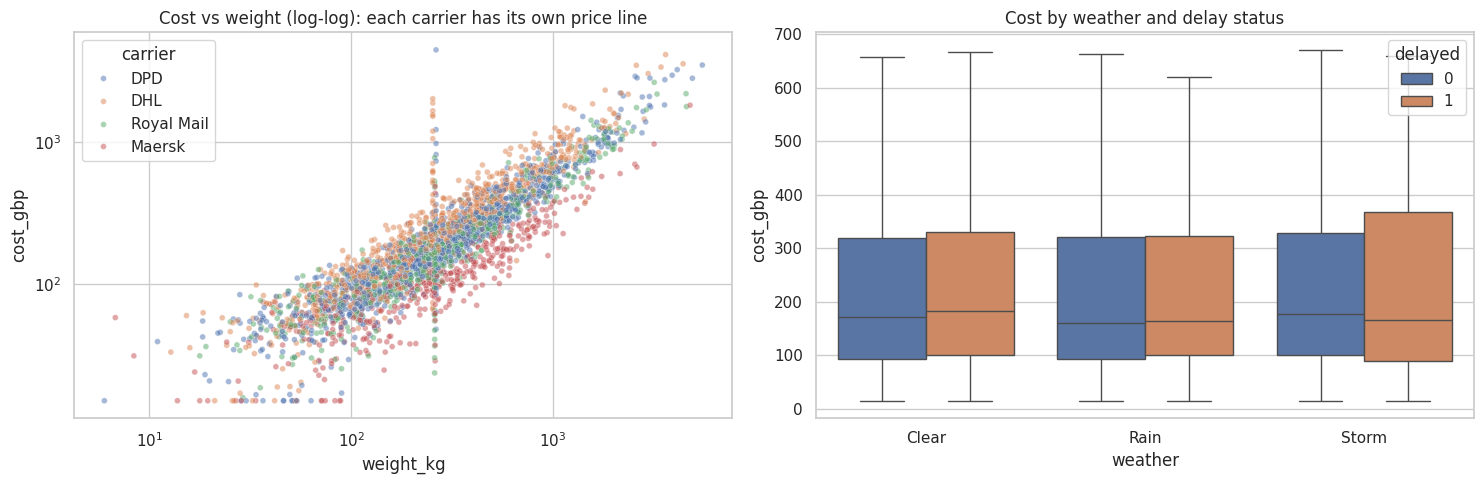

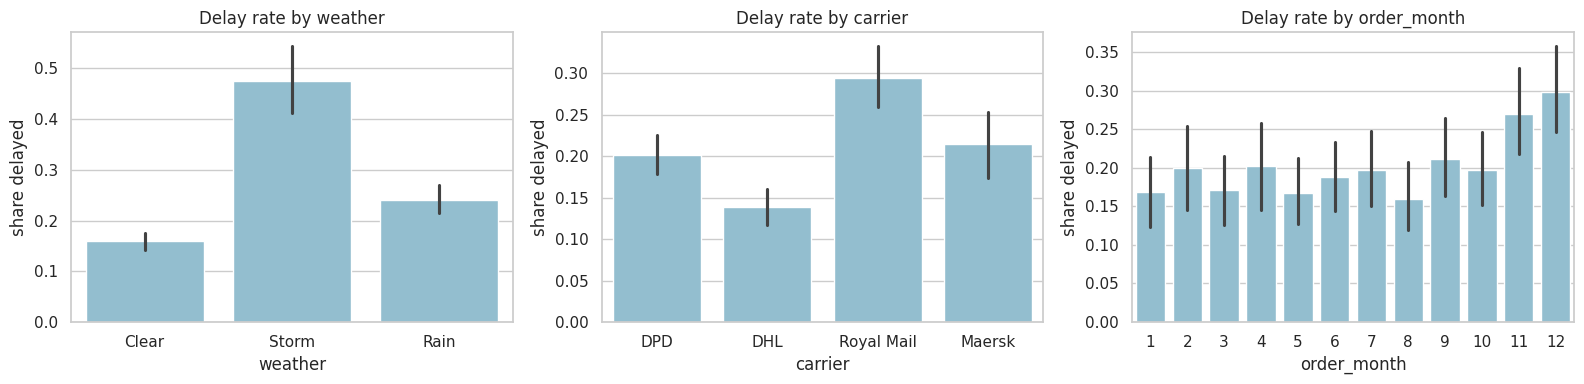

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.scatterplot(data=eda, x="weight_kg", y="cost_gbp", hue="carrier", alpha=0.5, s=18, ax=axes[0])
axes[0].set(xscale="log", yscale="log", title="Cost vs weight (log-log): each carrier has its own price line")

sns.boxplot(data=eda, x="weather", y="cost_gbp", hue="delayed", order=["Clear", "Rain", "Storm"],
            showfliers=False, ax=axes[1])
axes[1].set_title("Cost by weather and delay status")
plt.tight_layout(); plt.show()

# Delay rate by category - seaborn computes the mean AND a 95% confidence interval for each bar
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ["weather", "carrier", "order_month"]):
    sns.barplot(data=eda, x=col, y="delayed", ax=ax, color="#89c2d9", errorbar=("ci", 95))
    ax.set_title(f"Delay rate by {col}"); ax.set_ylabel("share delayed")
plt.tight_layout(); plt.show()

### Correlation heatmap

**Pearson correlation** $r$ measures the strength of a **linear** relationship between two numeric variables:

$$ r = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum (x_i - \bar{x})^2}\sqrt{\sum (y_i - \bar{y})^2}} \in [-1, 1] $$

It's the covariance rescaled by both standard deviations, so it is unit-free. $+1$ = perfect positive line, $-1$ = perfect negative line, $0$ = no *linear* relationship (there may still be a curved one!). **Spearman** correlation computes Pearson on the *ranks* instead, so it captures any monotonic relationship and is robust to outliers and skew — often the better choice for business data.

Why it matters for modelling:
- Features strongly correlated with the **target** are promising predictors.
- Features strongly correlated with **each other** (multicollinearity, e.g. weight and n_items) carry overlapping information; this makes linear-model coefficients unstable and hard to interpret.

⚠️ Correlation ≠ causation. Storms correlate with delays *and* with winter fuel prices — a heatmap can't tell you which causes what.

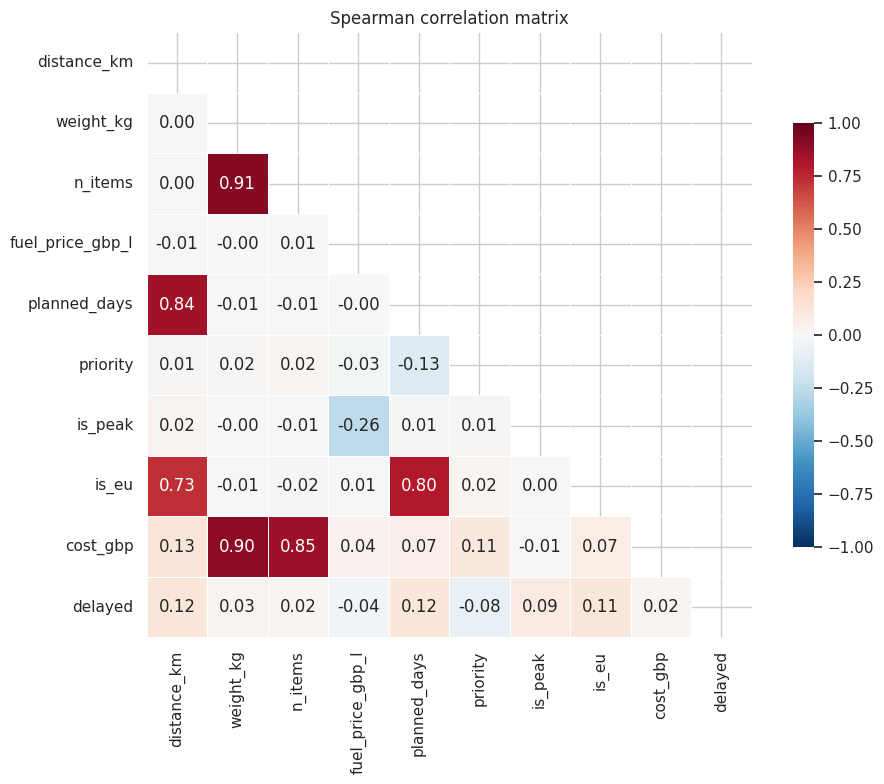

Correlation with cost:
 weight_kg           0.90
n_items             0.85
distance_km         0.13
priority            0.11
is_eu               0.07
planned_days        0.07
fuel_price_gbp_l    0.04
delayed             0.02
is_peak            -0.01
Name: cost_gbp, dtype: float64


In [16]:
corr_cols = ["distance_km", "weight_kg", "n_items", "fuel_price_gbp_l", "planned_days",
             "priority", "is_peak", "is_eu", "cost_gbp", "delayed"]
corr = eda[corr_cols].astype(float).corr(method="spearman")

mask = np.triu(np.ones_like(corr, dtype=bool))       # hide the redundant upper triangle
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1,
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.7}, ax=ax)
ax.set_title("Spearman correlation matrix")
plt.tight_layout(); plt.show()

print("Correlation with cost:\n", corr["cost_gbp"].drop("cost_gbp").sort_values(ascending=False).round(2))

### EDA takeaways (discuss with students before modelling)

1. **Cost is right-skewed** and driven mainly by weight, then distance; each carrier has a different price per kg.
2. **Weight and n_items are highly correlated** — expect them to share predictive credit.
3. **Delays rise with storms, long distances and peak season (Nov–Dec)**, and differ by carrier. Priority shipments are delayed less.
4. **Data quality:** we had dirty labels, invalid distances, and ~2–4% missing values in several columns.
5. The target `delayed` is **imbalanced** (fewer late than on-time shipments) — this will matter for evaluation in Part 2.

---
# PART 2 — Classical Machine Learning (Predictive Analytics)
---
## 2.1 The ML workflow and the golden rule

Supervised learning learns a function $f(\text{features}) \rightarrow \text{target}$ from labelled historical examples:
- **Regression** — target is a number (*cost in £*).
- **Classification** — target is a category (*delayed: yes/no*).

The workflow: **define target → split → preprocess → train → evaluate on unseen data → interpret → deploy**.

**The golden rule — avoid data leakage.** A model must be evaluated on data it has *never* seen in any form. Leakage happens when information from the test set sneaks into training, e.g.:
- computing an imputation median or scaling mean on the **whole** dataset before splitting;
- using a feature that is only known *after* the outcome (e.g. `actual_delivery_date` to predict delay).

Leaked models look brilliant in the notebook and fail in production. The fix is structural: **split first, then learn every preprocessing step from the training set only**. scikit-learn `Pipeline`s enforce this automatically.

Also note: we must drop `cost_per_kg` as a feature for predicting cost — it's *computed from the target*, a textbook leak.

## 2.2 Train–test split

`train_test_split` shuffles rows and holds back a fraction (commonly 20–25%) as a **test set** that simulates future, unseen shipments.

- `random_state` fixes the shuffle so results are reproducible.
- `stratify=y` (for classification) keeps the **same class proportions** in train and test. Without it, a small test set could by chance contain very few delayed shipments, making metrics noisy.

**Why not just train and test on the same data?** A flexible model can *memorise* training rows (overfitting). Training error then says nothing about performance on new shipments. The test set is our honest estimate of real-world performance — so we touch it **once**, at the end. For model selection and tuning we use **cross-validation** on the training set instead.

> In a real time-ordered business problem, you'd often split **by time** (train on Jan–Sep, test on Oct–Dec) to mimic how the model will actually be used. We use a random split here for simplicity.

In [17]:
from sklearn.model_selection import train_test_split

model_df = df.drop(columns=["cost_per_kg", "weight_band"])   # remove leak + a derived duplicate of weight

numeric_features     = ["distance_km", "weight_kg", "n_items", "fuel_price_gbp_l", "planned_days", "order_month"]
categorical_features = ["origin_warehouse", "destination_region", "carrier", "transport_mode", "weather"]
binary_features      = ["priority", "is_peak", "is_eu"]
features = numeric_features + categorical_features + binary_features

X = model_df[features].copy()
X[binary_features] = X[binary_features].astype(int)

# --- Regression target: cost ---
y_cost = model_df["cost_gbp"]
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X, y_cost, test_size=0.2, random_state=RANDOM_STATE)

# --- Classification target: delayed (stratified) ---
y_delay = model_df["delayed"]
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X, y_delay, test_size=0.2,
                                                            random_state=RANDOM_STATE, stratify=y_delay)

print(f"Regression   train {X_train_r.shape}, test {X_test_r.shape}")
print(f"Classification train {X_train_c.shape}, test {X_test_c.shape}")
print(f"Delay rate  - train {y_train_c.mean():.3f} | test {y_test_c.mean():.3f}  (stratify keeps these equal)")

Regression   train (2400, 14), test (600, 14)
Classification train (2400, 14), test (600, 14)
Delay rate  - train 0.203 | test 0.203  (stratify keeps these equal)


## 2.3 Preprocessing: categorical encoding, imputation, scaling

Models do arithmetic, so every input must be a number with no gaps.

**Categorical variables → One-Hot Encoding.** `carrier = "DPD"` becomes a set of 0/1 columns `carrier_DHL, carrier_DPD, carrier_Maersk, carrier_Royal Mail` with a single 1. Why not just code DHL=1, DPD=2, …? Because that invents a false *order* and *distance* (the model would think Maersk is "4× DHL"). One-hot avoids that. `handle_unknown="ignore"` makes the encoder output all zeros if a new, unseen carrier appears in production, instead of crashing.
(For *ordinal* categories with a genuine order — e.g. Bronze < Silver < Gold — use `OrdinalEncoder`. For very high-cardinality columns like postcodes, consider target or frequency encoding.)

**Missing values → `SimpleImputer`.** Median for numeric, most-frequent for categorical. The median is learned in `.fit()` on training data and re-used in `.transform()` on test data.

**Feature scaling → `StandardScaler`.** Transforms each numeric column to $z = (x - \mu) / \sigma$, i.e. mean 0 and standard deviation 1, using $\mu, \sigma$ **from the training set**.
- **Needed** for models that use distances or gradient-based optimisation with penalties: linear/logistic regression with regularisation, k-NN, SVMs, neural networks. Otherwise `weight_kg` (hundreds to thousands) would dominate `fuel_price` (≈1.5) purely because of its units.
- **Not needed** for tree-based models (decision trees, random forests, gradient boosting): they split on thresholds, which are unaffected by rescaling. It does no harm, though.

**Putting it together — `ColumnTransformer` + `Pipeline`.** A `ColumnTransformer` sends different columns through different preprocessing. A `Pipeline` chains preprocessing and the model into **one object** with a single `.fit()` / `.predict()`. Under the hood, `pipeline.fit(X_train, y)` calls `fit_transform` on each step in order using training data only, and `pipeline.predict(X_test)` calls only `transform` then `predict`. That's how pipelines make leakage structurally impossible — and they are what you'd deploy.

In [18]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale",  StandardScaler()),
])
categorical_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])
preprocessor = ColumnTransformer([
    ("num", numeric_pipe, numeric_features),
    ("cat", categorical_pipe, categorical_features),
    ("bin", "passthrough", binary_features),
])

# Peek inside: fit on TRAIN only, then transform
Xt = preprocessor.fit_transform(X_train_r)
feature_names = preprocessor.get_feature_names_out()
print(f"{X_train_r.shape[1]} raw columns -> {Xt.shape[1]} model-ready columns")
print(pd.DataFrame(Xt, columns=feature_names).iloc[:3, :12].round(2))

# Proof of scaling: training numeric columns now have mean ~0, std ~1
print("\nScaled means:", Xt[:, :len(numeric_features)].mean(axis=0).round(3))
print("Scaled stds: ", Xt[:, :len(numeric_features)].std(axis=0).round(3))
print("Learned training medians (used to fill gaps in test data):",
      dict(zip(numeric_features, preprocessor.named_transformers_["num"]["impute"].statistics_.round(2))))

14 raw columns -> 28 model-ready columns
   num__distance_km  num__weight_kg  num__n_items  num__fuel_price_gbp_l  \
0              1.00           -0.31         -0.64                  -1.15   
1              0.88           -0.08          0.29                   0.98   
2              0.80            0.17          0.51                  -0.12   

   num__planned_days  num__order_month  cat__origin_warehouse_Birmingham  \
0               2.72              0.71                              1.00   
1              -0.59             -0.45                              1.00   
2              -0.59              1.58                              1.00   

   cat__origin_warehouse_Felixstowe  cat__origin_warehouse_Manchester  \
0                              0.00                              0.00   
1                              0.00                              0.00   
2                              0.00                              0.00   

   cat__destination_region_EU-Benelux  cat__destination_

## 2.4 Regression: predicting logistics cost

We compare three models, from simplest to most flexible:

1. **Baseline — always predict the training mean.** Any useful model must beat this. It's the "do nothing" benchmark managers implicitly use.
2. **Linear Regression** — fits $\hat{y} = \beta_0 + \beta_1x_1 + \dots + \beta_px_p$ by **Ordinary Least Squares**: it chooses the $\beta$s that minimise the sum of squared errors $\sum(y_i - \hat{y}_i)^2$. There's a closed-form solution, so it trains instantly and is highly interpretable (each $\beta$ = change in £ per unit change in a feature, holding others fixed). Its limitation: it assumes effects are additive and linear. Our cost is really *multiplicative* (weight × rate × distance factor), so a linear model will struggle.
3. **Random Forest Regressor** — an **ensemble of decision trees**. Each tree recursively splits the data on the feature/threshold that most reduces squared error, ending in leaves that predict the average cost of their rows. A single deep tree overfits, so a random forest trains hundreds of trees, each on a **bootstrap sample** of rows (sampling with replacement) and considering a **random subset of features** at each split, then **averages** them. Averaging many de-correlated, noisy trees cancels out their individual errors (variance reduction) — this is *bagging*. Forests capture interactions and non-linearity automatically.

### Regression metrics

Let $e_i = y_i - \hat{y}_i$ be the error on shipment $i$:

| Metric | Formula | Interpretation |
|---|---|---|
| **MAE** | $\frac{1}{n}\sum \lvert e_i \rvert$ | Average absolute error in £. Easy to explain to managers. |
| **RMSE** | $\sqrt{\frac{1}{n}\sum e_i^2}$ | Also in £, but squaring **penalises large errors more**. RMSE ≥ MAE always; a big gap signals some very large misses. Use when big mistakes are disproportionately costly (e.g. budgeting). |
| **R²** | $1 - \frac{\sum e_i^2}{\sum (y_i - \bar{y})^2}$ | Share of cost variance explained, versus the mean baseline. 1 = perfect, 0 = no better than predicting the mean, negative = worse than the mean. |

**Cross-validation (k-fold):** split the training data into k folds; train on k−1 and score on the held-out fold, rotating k times. The mean score is a more stable estimate than one split; the standard deviation shows how sensitive the model is to which data it sees. We use this for model *comparison*, keeping the test set for the final verdict.

In [19]:
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

reg_models = {
    "Baseline (mean)":   DummyRegressor(strategy="mean"),
    "Linear Regression": LinearRegression(),
    "Random Forest":     RandomForestRegressor(n_estimators=300, min_samples_leaf=3,
                                               n_jobs=-1, random_state=RANDOM_STATE),
}

results, fitted_reg = [], {}
for name, model in reg_models.items():
    pipe = Pipeline([("prep", preprocessor), ("model", model)])
    cv_rmse = -cross_val_score(pipe, X_train_r, y_train_r, cv=5, scoring="neg_root_mean_squared_error")
    pipe.fit(X_train_r, y_train_r)
    pred = pipe.predict(X_test_r)
    fitted_reg[name] = pipe
    results.append({"model": name, "CV RMSE (train)": cv_rmse.mean(), "CV RMSE std": cv_rmse.std(),
                    "Test MAE": mean_absolute_error(y_test_r, pred), "Test RMSE": rmse(y_test_r, pred),
                    "Test R2": r2_score(y_test_r, pred)})

reg_results = pd.DataFrame(results).set_index("model")
reg_results

,CV RMSE (train),CV RMSE std,Test MAE,Test RMSE,Test R2
model,,,,,
Baseline (mean),378.43,37.50,204.19,296.87,-0.00
Linear Regression,166.68,37.05,67.39,122.53,0.83
Random Forest,132.36,34.63,39.45,79.43,0.93


### Diagnosing the regression model

A single number never tells the whole story. Two essential plots:

- **Predicted vs actual:** points should hug the diagonal $y = x$. Systematic bending means the model misses a pattern.
- **Residuals vs predicted:** residuals ($y - \hat{y}$) should scatter randomly around 0. A funnel shape (errors growing with cost) is **heteroscedasticity** — common with costs, and a hint that modelling `log(cost)` could help. A curve means missed non-linearity — exactly what we expect from the linear model here.

**Feature importance** (Random Forest, impurity-based): how much each feature reduced squared error across all splits in all trees, normalised to sum to 1. It's quick but biased toward continuous, high-cardinality features. **Permutation importance** is more trustworthy: shuffle one column in the *test* set and measure how much the score drops. If shuffling a feature barely hurts, the model didn't rely on it.

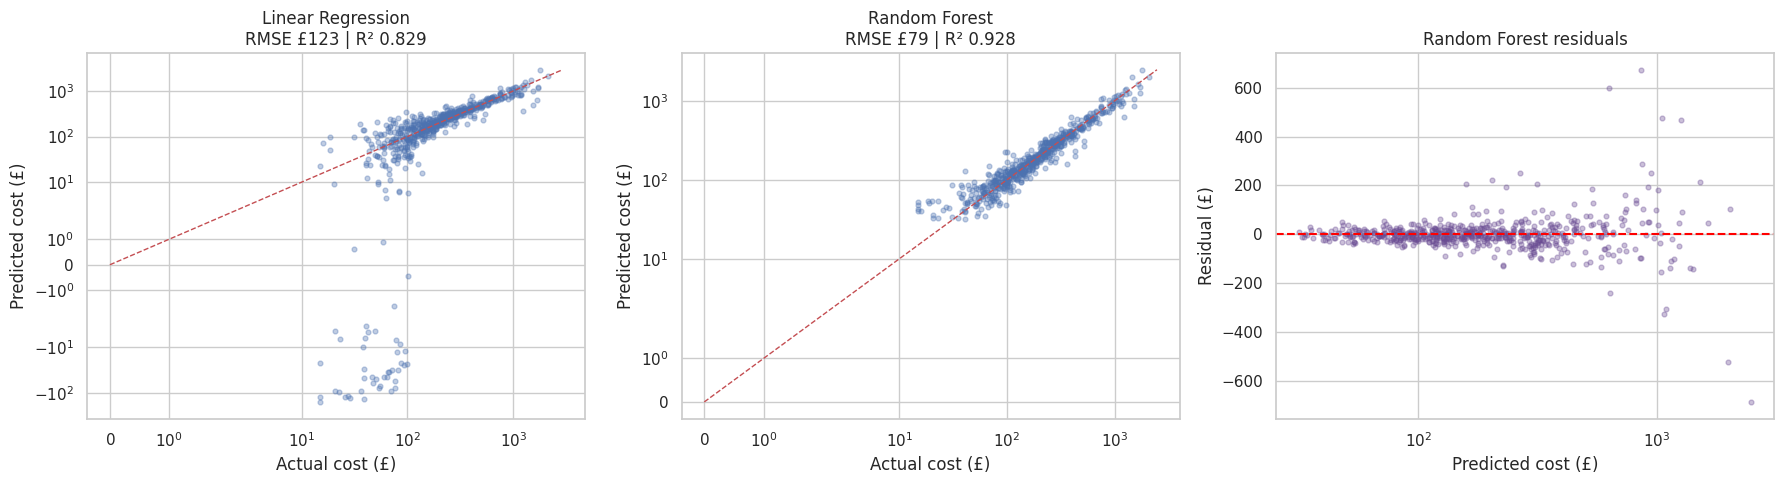

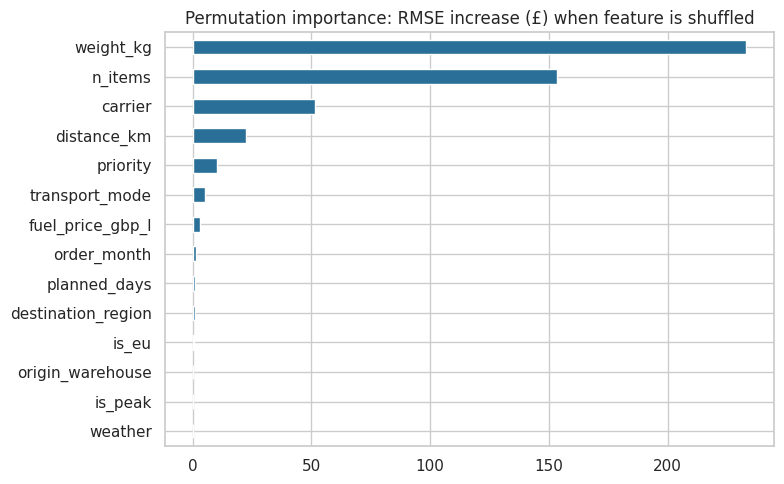

In [20]:
from sklearn.inspection import permutation_importance

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, name in zip(axes[:2], ["Linear Regression", "Random Forest"]):
    pred = fitted_reg[name].predict(X_test_r)
    ax.scatter(y_test_r, pred, alpha=0.35, s=12)
    lim = [0, max(y_test_r.max(), pred.max())]
    ax.plot(lim, lim, "r--", lw=1)
    ax.set(xscale="symlog", yscale="symlog", xlabel="Actual cost (£)", ylabel="Predicted cost (£)",
           title=f"{name}\nRMSE £{rmse(y_test_r, pred):,.0f} | R² {r2_score(y_test_r, pred):.3f}")

rf_pred = fitted_reg["Random Forest"].predict(X_test_r)
axes[2].scatter(rf_pred, y_test_r - rf_pred, alpha=0.35, s=12, color="#6a4c93")
axes[2].axhline(0, color="red", ls="--")
axes[2].set(xscale="log", xlabel="Predicted cost (£)", ylabel="Residual (£)", title="Random Forest residuals")
plt.tight_layout(); plt.show()

# Permutation importance on the TEST set (on raw columns, because the pipeline handles encoding)
perm = permutation_importance(fitted_reg["Random Forest"], X_test_r, y_test_r, n_repeats=5,
                              scoring="neg_root_mean_squared_error", random_state=RANDOM_STATE, n_jobs=-1)
imp = pd.Series(perm.importances_mean, index=X_test_r.columns).sort_values()
imp.plot.barh(figsize=(8, 5), color="#2a6f97",
              title="Permutation importance: RMSE increase (£) when feature is shuffled")
plt.tight_layout(); plt.show()

**Interpretation for the business:** the random forest explains the large majority of cost variance and cuts the typical error dramatically versus both the baseline and the linear model. Weight dominates, followed by carrier, distance and transport mode — matching how we built the data, which is reassuring: the model has discovered the true cost drivers. The linear model fails because the real cost structure is multiplicative.

> 💡 **Exercise:** train `LinearRegression` on `np.log(cost_gbp)` using `log(weight_kg)` and `log(distance_km)` as features (a log-log model turns multiplication into addition). How close does it get to the forest — while staying fully interpretable?

## 2.5 Classification: predicting delivery delays

Now the target is binary: `delayed` ∈ {0, 1}.

**Logistic Regression** — despite the name, a *classification* model. It computes a linear score $z = \beta_0 + \sum \beta_j x_j$ and squashes it through the **sigmoid** function $\sigma(z) = \frac{1}{1 + e^{-z}}$ to get a probability between 0 and 1. The $\beta$s are learned by **maximum likelihood** — choosing coefficients that make the observed outcomes most probable (equivalently, minimising *log loss*). Each coefficient is a change in the **log-odds** of delay; $e^{\beta}$ is an **odds ratio** (e.g. 2.0 = doubles the odds of delay). Scikit-learn applies L2 regularisation by default, which is why scaling matters here.

**Random Forest Classifier** — same bagging idea as before, but trees split to make leaves **purer** (measured by Gini impurity), and the forest's predicted probability is the average vote of the trees.

**Class imbalance:** only a minority of shipments are late. A lazy model that always predicts "on time" would score high *accuracy* while being useless. `class_weight="balanced"` makes errors on the rare class cost more during training, pushing the model to actually find delays.

**From probability to decision:** `predict_proba` gives $P(\text{delay})$; `predict` applies a **0.5 threshold** by default. The right threshold is a *business* decision — we'll return to this.

In [21]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, RocCurveDisplay)

clf_models = {
    "Baseline (majority)": DummyClassifier(strategy="most_frequent"),
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "Random Forest":       RandomForestClassifier(n_estimators=400, min_samples_leaf=5, class_weight="balanced",
                                                  n_jobs=-1, random_state=RANDOM_STATE),
}

rows, fitted_clf = [], {}
for name, model in clf_models.items():
    pipe = Pipeline([("prep", preprocessor), ("model", model)])
    pipe.fit(X_train_c, y_train_c)
    pred  = pipe.predict(X_test_c)
    proba = pipe.predict_proba(X_test_c)[:, 1]
    fitted_clf[name] = pipe
    rows.append({"model": name,
                 "Accuracy":  accuracy_score(y_test_c, pred),
                 "Precision": precision_score(y_test_c, pred, zero_division=0),
                 "Recall":    recall_score(y_test_c, pred),
                 "F1":        f1_score(y_test_c, pred),
                 "ROC-AUC":   roc_auc_score(y_test_c, proba)})

clf_results = pd.DataFrame(rows).set_index("model")
clf_results

,Accuracy,Precision,Recall,F1,ROC-AUC
model,,,,,
Baseline (majority),0.80,0.00,0.00,0.00,0.50
Logistic Regression,0.63,0.29,0.56,0.38,0.68
Random Forest,0.76,0.39,0.34,0.36,0.65


## 2.6 Evaluating classifiers: accuracy, the confusion matrix and beyond

### The confusion matrix
Every prediction falls into one of four cells. Here, **positive = delayed**:

|  | Predicted: on time (0) | Predicted: delayed (1) |
|---|---|---|
| **Actual: on time (0)** | **TN** — correctly cleared | **FP** — false alarm |
| **Actual: delayed (1)** | **FN** — missed delay ❗ | **TP** — delay caught |

All classification metrics are ratios of these four counts:

| Metric | Formula | Business question it answers |
|---|---|---|
| **Accuracy** | $\frac{TP+TN}{\text{all}}$ | What share of all predictions were right? *Misleading under imbalance* — the baseline above scores well by never predicting a delay. |
| **Precision** | $\frac{TP}{TP+FP}$ | When we flag a shipment as "will be late", how often are we right? (Cost of false alarms: wasted expediting, unnecessary customer calls.) |
| **Recall** (sensitivity) | $\frac{TP}{TP+FN}$ | Of all the shipments that actually were late, how many did we catch? (Cost of misses: angry customers, SLA penalties.) |
| **F1** | $2 \cdot \frac{P \cdot R}{P + R}$ | Harmonic mean — high only when *both* precision and recall are decent. |
| **ROC-AUC** | area under ROC curve | Threshold-free: the probability that a randomly chosen late shipment gets a higher risk score than a randomly chosen on-time one. 0.5 = coin flip, 1.0 = perfect ranking. |

**Precision–recall trade-off:** lowering the threshold flags more shipments → recall ↑, precision ↓. There's no free lunch; you pick the balance based on which error costs the business more.

              precision    recall  f1-score   support

     On time       0.85      0.65      0.74       478
     Delayed       0.29      0.56      0.38       122

    accuracy                           0.63       600
   macro avg       0.57      0.61      0.56       600
weighted avg       0.74      0.63      0.67       600



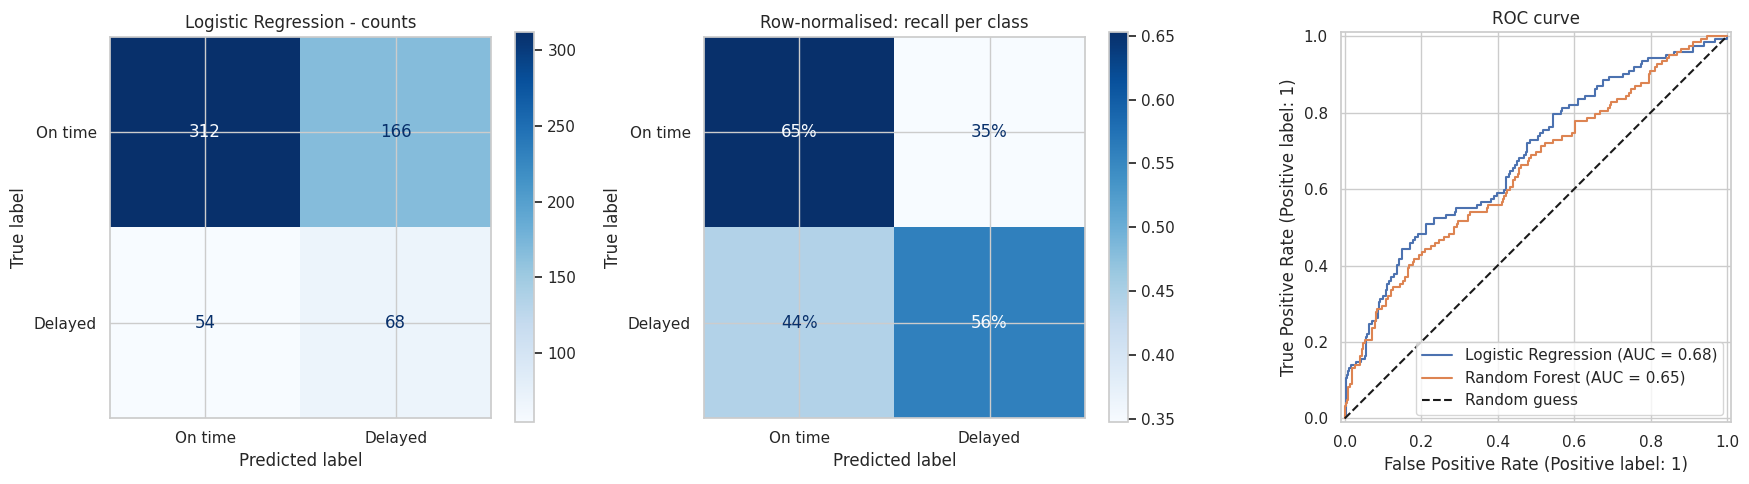

TN=312  FP=166  FN=54  TP=68
Accuracy  = (TP+TN)/all = (68+312)/600 = 0.633
Precision = TP/(TP+FP)  = 68/234 = 0.291
Recall    = TP/(TP+FN)  = 68/122 = 0.557


In [22]:
best = fitted_clf["Logistic Regression"]
y_pred = best.predict(X_test_c)
print(classification_report(y_test_c, y_pred, target_names=["On time", "Delayed"]))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ConfusionMatrixDisplay.from_predictions(y_test_c, y_pred, display_labels=["On time", "Delayed"],
                                        cmap="Blues", ax=axes[0])
axes[0].set_title("Logistic Regression - counts")
ConfusionMatrixDisplay.from_predictions(y_test_c, y_pred, display_labels=["On time", "Delayed"],
                                        normalize="true", cmap="Blues", values_format=".0%", ax=axes[1])
axes[1].set_title("Row-normalised: recall per class")

for name in ["Logistic Regression", "Random Forest"]:
    RocCurveDisplay.from_estimator(fitted_clf[name], X_test_c, y_test_c, name=name, ax=axes[2])
axes[2].plot([0, 1], [0, 1], "k--", label="Random guess")
axes[2].set_title("ROC curve"); axes[2].legend()
plt.tight_layout(); plt.show()

tn, fp, fn, tp = confusion_matrix(y_test_c, y_pred).ravel()
print(f"TN={tn}  FP={fp}  FN={fn}  TP={tp}")
print(f"Accuracy  = (TP+TN)/all = ({tp}+{tn})/{tn+fp+fn+tp} = {(tp+tn)/(tn+fp+fn+tp):.3f}")
print(f"Precision = TP/(TP+FP)  = {tp}/{tp+fp} = {tp/(tp+fp):.3f}")
print(f"Recall    = TP/(TP+FN)  = {tp}/{tp+fn} = {tp/(tp+fn):.3f}")

### Choosing a threshold with business costs

Suppose NorthStar estimates:
- a **missed delay** (FN) costs **£120** (SLA penalty + customer service time);
- a **false alarm** (FP) costs **£25** (a proactive check or re-routing that wasn't needed).

Rather than accepting 0.5, we sweep thresholds and pick the one that minimises **expected total cost**. This is where analytics turns into a decision: the "best" model setting depends on the business's cost structure, not on a textbook metric.

We also inspect the logistic regression **odds ratios** to explain *why* shipments are flagged — interpretability that stakeholders need before trusting a model.

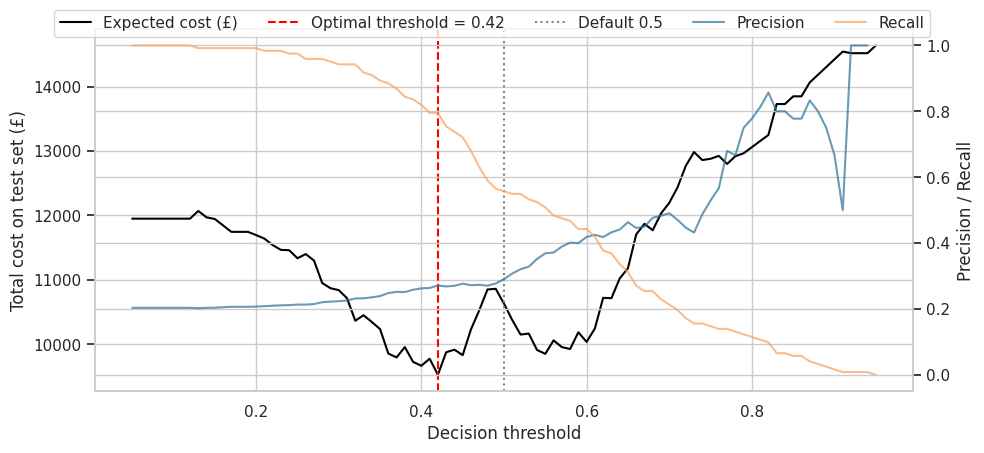

Cost at 0.5: £10,630 | at optimal 0.42: £9,525

Top delay drivers (odds ratio > 1 increases risk; numeric features are per 1 std):
num__distance_km          1.28
bin__is_eu                1.36
cat__transport_mode_Sea   1.37
bin__is_peak              1.47
cat__carrier_Royal Mail   1.62
cat__weather_Storm        2.80

Top protective factors (odds ratio < 1):
bin__priority        0.47
cat__weather_Clear   0.49
cat__carrier_DHL     0.67
num__planned_days    0.83


In [23]:
COST_FN, COST_FP = 120, 25
proba = best.predict_proba(X_test_c)[:, 1]
thresholds = np.linspace(0.05, 0.95, 91)
sweep = []
for t in thresholds:
    tn, fp, fn, tp = confusion_matrix(y_test_c, (proba >= t).astype(int)).ravel()
    sweep.append({"threshold": t, "cost": fn * COST_FN + fp * COST_FP,
                  "precision": tp / (tp + fp) if tp + fp else np.nan, "recall": tp / (tp + fn)})
sweep = pd.DataFrame(sweep)
best_t = sweep.loc[sweep["cost"].idxmin()]

fig, ax1 = plt.subplots(figsize=(10, 4.5))
ax1.plot(sweep["threshold"], sweep["cost"], color="black", label="Expected cost (£)")
ax1.axvline(best_t["threshold"], color="red", ls="--", label=f"Optimal threshold = {best_t['threshold']:.2f}")
ax1.axvline(0.5, color="grey", ls=":", label="Default 0.5")
ax1.set(xlabel="Decision threshold", ylabel="Total cost on test set (£)")
ax2 = ax1.twinx()
ax2.plot(sweep["threshold"], sweep["precision"], color="#2a6f97", alpha=0.7, label="Precision")
ax2.plot(sweep["threshold"], sweep["recall"], color="#f4a261", alpha=0.7, label="Recall")
ax2.set_ylabel("Precision / Recall")
fig.legend(loc="upper center", ncol=5, bbox_to_anchor=(0.5, 1.02)); plt.tight_layout(); plt.show()

cost_at_05 = sweep.iloc[(sweep["threshold"] - 0.5).abs().argmin()]["cost"]
print(f"Cost at 0.5: £{cost_at_05:,.0f} | at optimal {best_t['threshold']:.2f}: £{best_t['cost']:,.0f}")

# Interpretability: odds ratios from logistic regression
coefs = pd.Series(best.named_steps["model"].coef_[0],
                  index=best.named_steps["prep"].get_feature_names_out())
odds = np.exp(coefs).sort_values()
print("\nTop delay drivers (odds ratio > 1 increases risk; numeric features are per 1 std):")
print(odds.tail(6).round(2).to_string())
print("\nTop protective factors (odds ratio < 1):")
print(odds.head(4).round(2).to_string())

### Part 2 wrap-up

| Model | Strengths | Weaknesses | When to use |
|---|---|---|---|
| Linear / Logistic regression | Fast, interpretable coefficients, stable | Assumes linear (log-odds) relationships | Explaining drivers to stakeholders; baseline; regulated settings |
| Random Forest | Captures non-linearity & interactions, little tuning, robust | Less interpretable, larger models | Strong default for tabular data |
| Gradient boosting (XGBoost / LightGBM / `HistGradientBoosting`) | Often the most accurate on tabular data | More hyperparameters, easier to overfit | Competitions, production accuracy |

Notice that the forest was the clear winner for **cost** (strongly non-linear), while logistic regression competes well for **delay** — because we generated delay through a logistic-style process. Also notice that delay is much *harder* to predict (ROC-AUC ≈ 0.68) than cost (R² ≈ 0.93): lateness contains a lot of genuine randomness that no feature captures. That is realistic — and a good discussion point about setting stakeholder expectations. **Model choice should follow the structure of the problem, not fashion.**

> 💡 **Exercises:** (1) Tune the random forest with `GridSearchCV` over `n_estimators` and `min_samples_leaf`. (2) Try `HistGradientBoostingClassifier`. (3) Re-split by time (train Jan–Sep, test Oct–Dec) and see whether the performance holds up in peak season.

---
# PART 3 — Advanced ML & Generative AI (LangChain & RAG)
---
> ⚙️ **Before continuing:** set **Runtime → Change runtime type → T4 GPU**. The code also runs on CPU, just much more slowly. If you change runtime now, re-run the setup cell (and the imports cell) first.

## 3.1 From predictive ML to generative AI

In Part 2, models learned a narrow mapping from structured features to one number. **Large Language Models (LLMs)** are trained on vast text corpora to do one deceptively simple thing: **predict the next token** (a word or word-piece) given all previous tokens. Repeat that prediction, append the token, and predict again — this *autoregressive* loop generates fluent text. Under the hood, a **Transformer** architecture uses *self-attention* to weigh how relevant every earlier token is to predicting the next one.

**Instruct / chat models** are further fine-tuned to follow instructions in a conversation format with **roles**: `system` (sets behaviour), `user` (the question), `assistant` (the reply). Each model family expects its own special formatting tokens — a **chat template** — which the tokenizer applies for us.

### Why an open-source model?
Hosted APIs (OpenAI, Anthropic, Google) need keys and billing. For a teaching notebook we download a small open model from **Hugging Face** and run it **inside the Colab session**, so every student can run it free with no account.

We'll use **`Qwen/Qwen2.5-1.5B-Instruct`** (1.5 billion parameters, Apache-2.0 licence). In 16-bit precision it needs about 3–4 GB of GPU memory, which fits comfortably on Colab's free T4 (15 GB). On a CPU-only runtime we fall back to the 0.5B version. Small models are fast and cheap but less knowledgeable and more error-prone than frontier models — a useful lesson in itself.

### What LangChain adds
**LangChain** is an orchestration framework: it gives a common interface to models, prompts, retrievers and vector stores, and lets you compose them with the pipe operator `|` (the *LangChain Expression Language*, LCEL):
```python
chain = prompt | llm | output_parser
chain.invoke({"question": "..."})
```
Each component is a *Runnable*; `|` feeds the output of one into the next — the same idea as a scikit-learn `Pipeline`, but for text.

In [24]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline

has_gpu = torch.cuda.is_available()
MODEL_ID = "Qwen/Qwen2.5-1.5B-Instruct" if has_gpu else "Qwen/Qwen2.5-0.5B-Instruct"
print("GPU:", torch.cuda.get_device_name(0) if has_gpu else "none (CPU fallback - slower, smaller model)")
print("Loading", MODEL_ID, "...")

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16 if has_gpu else torch.float32,   # half precision halves GPU memory
    device_map="auto",                                            # put weights on GPU if available
)

gen_pipe = pipeline(
    "text-generation", model=model, tokenizer=tokenizer,
    max_new_tokens=300,        # cap answer length
    do_sample=False,           # greedy decoding = deterministic, factual-style answers
    repetition_penalty=1.1,
    return_full_text=False,    # return only the newly generated text, not the prompt
)
print(f"Loaded. Parameters: {model.num_parameters()/1e9:.2f}B")

GPU: Tesla T4
Loading Qwen/Qwen2.5-1.5B-Instruct ...


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'do_sample', 'max_new_tokens', 'repetition_penalty'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


Loaded. Parameters: 1.54B


### Wrapping the model for LangChain and writing a first prompt

- `HuggingFacePipeline` wraps the transformers pipeline as a LangChain LLM.
- `ChatHuggingFace` adds chat support: it converts LangChain messages (system/human) into the model's own **chat template** automatically.
- `ChatPromptTemplate` defines a reusable prompt with `{placeholders}`. Keeping prompts as templates (not hard-coded strings) makes them testable and versionable — *prompt engineering* is part of the model.
- `StrOutputParser` extracts plain text from the model's message object.

**Temperature & sampling:** with `do_sample=False` the model always picks the most likely next token (greedy) — good for factual Q&A. Enabling sampling with a temperature > 0 adds randomness for creative tasks.

Notice in the output: without access to NorthStar's documents, the model can only answer from general knowledge — and may confidently **hallucinate** company-specific details. That's the problem RAG solves.

In [25]:
from langchain_huggingface import HuggingFacePipeline, ChatHuggingFace
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

llm = HuggingFacePipeline(pipeline=gen_pipe, model_id=MODEL_ID)
chat_model = ChatHuggingFace(llm=llm, tokenizer=tokenizer, model_id=MODEL_ID)   # applies Qwen's chat template

prompt = ChatPromptTemplate.from_messages([
    ("system", "You are a concise supply-chain analyst. Answer in at most 4 sentences."),
    ("human", "{question}"),
])
basic_chain = prompt | chat_model | StrOutputParser()

print(basic_chain.invoke({"question": "Explain the difference between RMSE and MAE to a logistics manager."}))
print("\n" + "-" * 80 + "\n")
# A company-specific question the model cannot know -> watch for a confident guess (hallucination)
print(basic_chain.invoke({"question": "What is NorthStar Logistics' compensation policy for delayed priority shipments?"}))

[transformers] The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
[transformers] Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer Qwen2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.
[transformers] Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the docum

Root Mean Squared Error (RMSE) measures the average magnitude of errors without considering their direction, making it sensitive to large errors. Mean Absolute Error (MAE), on the other hand, calculates the average of the absolute values of the errors, which is less affected by outliers but may not reflect the actual size of the error as accurately. Both metrics help assess prediction accuracy but serve different purposes depending on whether you want to penalize larger errors or focus more on overall performance.

--------------------------------------------------------------------------------

NorthStar Logistics does not have an explicit public policy on the specific compensation for delayed priority shipments, as such policies can vary by company and may be confidential or subject to internal guidelines. However, generally speaking, companies with strict priority shipping programs might offer higher compensation or additional incentives to drivers who complete deliveries within the

## 3.2 Retrieval-Augmented Generation (RAG) — in plain English

**The problem:** an LLM only knows what was in its training data. It doesn't know your company's policy manual, last month's contracts or yesterday's incident report — and when asked, it may invent a plausible-sounding answer.

**The idea:** don't retrain the model. Instead, **look up the relevant passages first, then hand them to the model with the question**, and instruct it to answer *only* from those passages. It's an **open-book exam**: the model's job shifts from *remembering* facts to *reading and summarising* the right page.

### The RAG pipeline, step by step

```
            ── INDEXING (done once, offline) ──────────────────────────────────────────────
  📄 Documents ──► ✂️ Chunking ──► 🔢 Embeddings ──► 🗄️ Vector store
                                                          │
            ── QUERYING (every question) ─────────────────┼────────────────────────────────
  ❓ Question ──► 🔢 Embed question ──► 🔎 Retrieve top-k similar chunks
                                                          │
                          📝 Prompt = instructions + retrieved chunks + question
                                                          │
                                                   🤖 LLM ──► ✅ Grounded answer + sources
```

1. **Document loading** — read source files (PDF, Word, web pages, text) into `Document` objects: the text plus **metadata** (file name, page, date) so we can cite sources later.

2. **Chunking** — split documents into small, overlapping pieces (e.g. ~500 characters with 80 overlap). Why? (a) the model's context window is limited; (b) a small chunk about *one* topic gives a sharper embedding than a whole manual, so retrieval is more precise; (c) **overlap** ensures a sentence cut at a boundary still appears whole in one chunk. Chunk size is a key tuning knob: too small loses context, too large dilutes relevance.

3. **Embeddings** — an *embedding model* converts each chunk into a vector of numbers (here 384 dimensions) that captures its **meaning**. Texts with similar meaning land close together in this space, even with different words: *"late delivery compensation"* sits near *"refund for delayed shipments"*. This is what makes semantic search better than keyword search. We use `all-MiniLM-L6-v2`, a small, fast sentence-transformer that runs well on CPU.

4. **Vector storage** — save all chunk vectors in a **vector database** (FAISS, ChromaDB, Pinecone…) that is optimised for one operation: *given a query vector, find the nearest stored vectors quickly*. Similarity is usually **cosine similarity**, the cosine of the angle between two vectors (1 = same direction/meaning).

5. **Retrieval** — at question time, embed the question with the **same** embedding model, find the top-*k* most similar chunks, and pass them to the LLM inside a prompt that says *"answer only from this context; if it's not there, say so."*

### Why businesses use RAG (versus fine-tuning)
| | RAG | Fine-tuning |
|---|---|---|
| Update knowledge | Re-index a document — minutes | Retrain the model — expensive |
| Cite sources / audit | ✓ Shows which chunks were used | ✗ Knowledge is baked into weights |
| Reduce hallucination on company facts | ✓ Grounded in retrieved text | Partial |
| Change tone / format / behaviour | Limited | ✓ Its real strength |
| Access control | Filter what each user can retrieve | Hard |

**Failure modes to teach:** if retrieval fetches the wrong chunks, even a perfect LLM gives a wrong answer ("garbage in, garbage out"). Most RAG debugging is *retrieval* debugging — so always inspect what was retrieved.

## 3.3 RAG implementation

### Step 1 — Create and load the document

We write NorthStar's (fictional) **logistics operations policy** to a text file — in practice, this would be your organisation's own PDFs or SharePoint pages (swap `TextLoader` for `PyPDFLoader`, `Docx2txtLoader`, `WebBaseLoader`, etc.). Notice the loader returns a list of `Document` objects, each with `page_content` and `metadata`.

In [26]:
policy_text = """NorthStar Logistics - Operations & Service Policy Manual (v3.2, effective 1 March 2025)

SECTION 1: SERVICE LEVELS
1.1 Standard shipments within Great Britain have a target delivery window of 3 working days from dispatch. Shipments to Scotland are allowed 4 working days.
1.2 Priority shipments within Great Britain must be delivered within 1 working day. Priority service is available only for consignments under 1,000 kg.
1.3 Shipments to the European Union (Benelux and Germany) have a target of 5 working days by road and 9 working days by sea, excluding customs clearance delays.
1.4 The company-wide on-time delivery target is 90 percent measured monthly. Each carrier's performance is reviewed against its contracted SLA every quarter.

SECTION 2: CARRIER MANAGEMENT
2.1 NorthStar holds contracts with four carriers: DHL (Gold tier), DPD (Silver tier), Royal Mail (Silver tier) and Maersk (Bronze tier, sea freight only).
2.2 Gold-tier carriers are contracted to 90 percent on-time performance, Silver-tier to 85 percent and Bronze-tier to 80 percent.
2.3 A carrier that misses its SLA target for two consecutive quarters is placed on a 60-day performance improvement plan. If performance does not recover, volume is reallocated to other carriers by up to 30 percent.
2.4 Freight over 1,000 kg to EU destinations should be routed via Maersk sea freight unless the customer has paid for priority service.

SECTION 3: DELAYS AND CUSTOMER COMPENSATION
3.1 A shipment is classified as delayed if it arrives more than 24 hours after its promised delivery window.
3.2 Customers must be notified proactively by email within 4 hours of a delay being identified by the operations team.
3.3 Standard delayed shipments receive a service credit of 10 percent of the shipping charge.
3.4 Delayed priority shipments receive a full refund of the priority surcharge plus a service credit of 15 percent of the base shipping charge.
3.5 Compensation is not payable for delays caused by severe weather warnings issued by the Met Office (amber or red), strikes, or customs inspections. These are classed as force majeure events.
3.6 Compensation claims must be submitted by the customer within 30 days of the delivery date.

SECTION 4: PEAK SEASON OPERATIONS
4.1 The peak season runs from 1 November to 31 December. During peak season, delivery windows for standard shipments are extended by 1 working day.
4.2 Warehouses operate extended shifts (6am to 11pm) during peak season, and agency staffing may increase by up to 40 percent.
4.3 New customer onboarding is paused from 15 November to 5 January to protect service levels.

SECTION 5: COST CONTROL AND PRICING
5.1 Shipping charges are calculated on the greater of actual weight and volumetric weight. Volumetric weight equals length x width x height in centimetres divided by 5,000.
5.2 A fuel surcharge is reviewed monthly and applied when the average UK diesel price exceeds 1.50 GBP per litre. The surcharge is 1 percent for every 5 pence above that threshold.
5.3 Any single shipment with an estimated cost above 2,500 GBP requires approval from a regional operations manager before dispatch.
5.4 Analytics teams must re-train cost prediction models at least once per quarter and monitor prediction error monthly. If the RMSE rises by more than 20 percent from its baseline, the model must be reviewed.

SECTION 6: DATA AND AI GOVERNANCE
6.1 Customer personal data may only be used in analytics projects after pseudonymisation.
6.2 Any generative AI assistant used by staff must answer only from approved internal documents and must display its sources.
6.3 Decisions to refuse compensation must be reviewed by a human; they cannot be made solely by an automated system.
"""

with open("northstar_policy.txt", "w", encoding="utf-8") as f:
    f.write(policy_text)

from langchain_community.document_loaders import TextLoader

docs = TextLoader("northstar_policy.txt", encoding="utf-8").load()
print(f"Loaded {len(docs)} document(s) | {len(docs[0].page_content):,} characters")
print("Metadata:", docs[0].metadata)
print(docs[0].page_content[:300], "...")

Loaded 1 document(s) | 3,718 characters
Metadata: {'source': 'northstar_policy.txt'}
NorthStar Logistics - Operations & Service Policy Manual (v3.2, effective 1 March 2025)

SECTION 1: SERVICE LEVELS
1.1 Standard shipments within Great Britain have a target delivery window of 3 working days from dispatch. Shipments to Scotland are allowed 4 working days.
1.2 Priority shipments withi ...


### Step 2 — Chunking

`RecursiveCharacterTextSplitter` is the standard choice. It tries to split on the **most natural boundary first** — paragraph breaks (`"\n\n"`), then line breaks, then sentences (`". "`), then spaces — and only falls back to smaller separators when a piece is still bigger than `chunk_size`. This keeps related sentences together.

- `chunk_size=500` — maximum characters per chunk (≈ 100–120 tokens).
- `chunk_overlap=80` — the last ~80 characters of one chunk are repeated at the start of the next, so ideas spanning a boundary aren't lost.
- `add_start_index=True` — records where each chunk came from in the original text (useful for citations).

In [27]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

splitter = RecursiveCharacterTextSplitter(
    chunk_size=500, chunk_overlap=80,
    separators=["\n\n", "\n", ". ", " ", ""],
    add_start_index=True,
)
chunks = splitter.split_documents(docs)

lengths = [len(c.page_content) for c in chunks]
print(f"{len(chunks)} chunks | length min {min(lengths)}, mean {np.mean(lengths):.0f}, max {max(lengths)}")
for i, c in enumerate(chunks[:3]):
    print(f"\n--- chunk {i} (start index {c.metadata['start_index']}) ---\n{c.page_content}")

11 chunks | length min 87, mean 336, max 495

--- chunk 0 (start index 0) ---
NorthStar Logistics - Operations & Service Policy Manual (v3.2, effective 1 March 2025)

--- chunk 1 (start index 89) ---
SECTION 1: SERVICE LEVELS
1.1 Standard shipments within Great Britain have a target delivery window of 3 working days from dispatch. Shipments to Scotland are allowed 4 working days.
1.2 Priority shipments within Great Britain must be delivered within 1 working day. Priority service is available only for consignments under 1,000 kg.
1.3 Shipments to the European Union (Benelux and Germany) have a target of 5 working days by road and 9 working days by sea, excluding customs clearance delays.

--- chunk 2 (start index 585) ---
1.4 The company-wide on-time delivery target is 90 percent measured monthly. Each carrier's performance is reviewed against its contracted SLA every quarter.


### Step 3 — Embeddings

`HuggingFaceEmbeddings` downloads **`sentence-transformers/all-MiniLM-L6-v2`** (~90 MB) and runs it locally. Each chunk becomes a **384-dimensional vector**. `normalize_embeddings=True` scales each vector to length 1, so a dot product equals cosine similarity.

Below we demonstrate the core intuition directly: sentences with the **same meaning but different words** get a high cosine similarity; unrelated sentences score low. This is the mathematical heart of semantic search.

In [28]:
from langchain_huggingface import HuggingFaceEmbeddings

embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2",
    model_kwargs={"device": "cuda" if has_gpu else "cpu"},
    encode_kwargs={"normalize_embeddings": True},
)

sentences = [
    "Customers get money back when a priority parcel arrives late.",           # A
    "Delayed priority shipments receive a refund of the priority surcharge.",  # B - same meaning as A, different words
    "Warehouses operate extended shifts during peak season.",                  # C - unrelated
]
vecs = np.array(embeddings.embed_documents(sentences))
print("Embedding shape:", vecs.shape, "| first 6 values of A:", vecs[0][:6].round(3))

sim = vecs @ vecs.T      # vectors are normalised, so dot product = cosine similarity
print(pd.DataFrame(sim, index=["A", "B", "C"], columns=["A", "B", "C"]).round(3))
print("\nA vs B (same meaning):", sim[0, 1].round(3), "| A vs C (unrelated):", sim[0, 2].round(3))

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding shape: (3, 384) | first 6 values of A: [-0.041 -0.016  0.051 -0.012 -0.02   0.012]
     A    B    C
A 1.00 0.67 0.22
B 0.67 1.00 0.14
C 0.22 0.14 1.00

A vs B (same meaning): 0.666 | A vs C (unrelated): 0.224


### Step 4 — Vector storage (FAISS)

**FAISS** (Facebook AI Similarity Search) stores vectors in an index optimised for nearest-neighbour search. `FAISS.from_documents` embeds every chunk and builds the index in memory. For a few hundred chunks, it does exact search; for millions, FAISS offers approximate indexes (IVF, HNSW) that trade a tiny bit of accuracy for huge speed-ups.

`similarity_search_with_score` lets us look **inside** retrieval — always do this when debugging RAG. With FAISS's default metric, the score is a **distance** (lower = more similar).

We also save the index to disk (`save_local`), so it doesn't need rebuilding each time — that's the "index once, query many times" pattern.

> **Using ChromaDB instead:** Chroma is a vector database with built-in persistence and metadata filtering. The swap is one line (shown commented below); the rest of the chain is unchanged, because both implement LangChain's common `VectorStore` interface.

In [29]:
from langchain_community.vectorstores import FAISS

vectorstore = FAISS.from_documents(chunks, embeddings)
vectorstore.save_local("northstar_faiss_index")
print(f"Indexed {vectorstore.index.ntotal} vectors of dimension {vectorstore.index.d}")

# --- Optional alternative: ChromaDB (persisted to disk) ---
# from langchain_chroma import Chroma
# vectorstore = Chroma.from_documents(chunks, embeddings, collection_name="northstar_policy",
#                                     persist_directory="./chroma_db")

query = "What do customers get if a priority delivery is late?"
for doc, score in vectorstore.similarity_search_with_score(query, k=3):
    print(f"\n[distance {score:.3f}] {doc.page_content[:220]}...")

Indexed 11 vectors of dimension 384

[distance 0.640] SECTION 3: DELAYS AND CUSTOMER COMPENSATION
3.1 A shipment is classified as delayed if it arrives more than 24 hours after its promised delivery window.
3.2 Customers must be notified proactively by email within 4 hours ...

[distance 0.702] 3.4 Delayed priority shipments receive a full refund of the priority surcharge plus a service credit of 15 percent of the base shipping charge.
3.5 Compensation is not payable for delays caused by severe weather warnings...

[distance 1.072] SECTION 1: SERVICE LEVELS
1.1 Standard shipments within Great Britain have a target delivery window of 3 working days from dispatch. Shipments to Scotland are allowed 4 working days.
1.2 Priority shipments within Great B...


### Step 5 — Retrieval + generation: the RAG chain

We now connect everything with LCEL:

```python
rag_chain = (
    {"context": retriever | format_docs,       # 1. embed question -> fetch top-k chunks -> join into text
     "question": RunnablePassthrough()}        # 2. pass the original question through unchanged
    | rag_prompt                               # 3. fill the prompt template
    | chat_model                               # 4. LLM generates an answer
    | StrOutputParser()                        # 5. extract the text
)
```

- `vectorstore.as_retriever(search_kwargs={"k": 4})` turns the store into a *Retriever* Runnable: text in, top-4 `Document`s out.
- The dictionary `{...}` runs its branches **in parallel** on the same input and produces `{"context": ..., "question": ...}` for the prompt.
- The **system prompt is the guardrail**: answer only from the context, say "I don't know" if the answer isn't there, and cite the section numbers. This directly implements policy 6.2 of our own document!

We also return the **source chunks** alongside each answer, so users (and auditors) can verify it.

In [30]:
from langchain_core.runnables import RunnablePassthrough, RunnableParallel

retriever = vectorstore.as_retriever(search_type="similarity", search_kwargs={"k": 4})

def format_docs(docs):
    return "\n\n".join(f"[Excerpt {i+1}]\n{d.page_content}" for i, d in enumerate(docs))

rag_prompt = ChatPromptTemplate.from_messages([
    ("system",
     "You are NorthStar Logistics' internal policy assistant. Answer the question using ONLY the "
     "policy excerpts provided. Quote the relevant section numbers (e.g. 'Section 3.4'). If the excerpts "
     "do not contain the answer, reply exactly: \"I can't find that in the policy manual.\" "
     "Be concise: at most 4 sentences."),
    ("human", "Policy excerpts:\n{context}\n\nQuestion: {question}"),
])

rag_chain = (
    {"context": retriever | format_docs, "question": RunnablePassthrough()}
    | rag_prompt
    | chat_model
    | StrOutputParser()
)

# Variant that also returns the retrieved sources (for citations / auditing)
rag_with_sources = RunnableParallel(
    {"docs": retriever, "question": RunnablePassthrough()}
).assign(answer=(lambda x: {"context": format_docs(x["docs"]), "question": x["question"]})
                | rag_prompt | chat_model | StrOutputParser())

def ask(question: str):
    out = rag_with_sources.invoke(question)
    print(f"Q: {question}\nA: {out['answer'].strip()}")
    print("Sources:", [d.page_content.split(chr(10))[0][:70] + "..." for d in out["docs"][:2]])
    print("-" * 100)

ask("What is NorthStar Logistics' compensation policy for delayed priority shipments?")
ask("Do we pay compensation if a delay was caused by a red weather warning?")
ask("How often must the cost prediction model be retrained, and when must it be reviewed?")
ask("Which carrier should I use for a 1,500 kg non-priority shipment to Germany?")
ask("What is the CEO's salary?")     # not in the document -> should refuse, not hallucinate

[transformers] Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Q: What is NorthStar Logistics' compensation policy for delayed priority shipments?
A: According to Section 3.4 of the Operations & Service Policy Manual, NorthStar Logistics provides a full refund of the priority surcharge plus a service credit of 15 percent of the base shipping charge for delayed priority shipments.
Sources: ['3.4 Delayed priority shipments receive a full refund of the priority s...', 'NorthStar Logistics - Operations & Service Policy Manual (v3.2, effect...']
----------------------------------------------------------------------------------------------------


[transformers] Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Q: Do we pay compensation if a delay was caused by a red weather warning?
A: No, according to Section 3.5 of the policy manual, compensation is not payable for delays caused by severe weather warnings issued by the Met Office (amber or red).
Sources: ['3.4 Delayed priority shipments receive a full refund of the priority s...', 'SECTION 3: DELAYS AND CUSTOMER COMPENSATION...']
----------------------------------------------------------------------------------------------------


[transformers] Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Q: How often must the cost prediction model be retrained, and when must it be reviewed?
A: According to Excerpts 1 and 2, the analytics team must retrain their cost prediction models at least once per quarter and monitor prediction error monthly. If the RMSE (Root Mean Squared Error) rises by more than 20 percent from its baseline, the model must be reviewed.
Sources: ['5.3 Any single shipment with an estimated cost above 2,500 GBP require...', 'SECTION 5: COST CONTROL AND PRICING...']
----------------------------------------------------------------------------------------------------


[transformers] Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Q: Which carrier should I use for a 1,500 kg non-priority shipment to Germany?
A: Maersk should be used for a 1,500 kg non-priority shipment to Germany.
Sources: ['2.3 A carrier that misses its SLA target for two consecutive quarters ...', 'SECTION 1: SERVICE LEVELS...']
----------------------------------------------------------------------------------------------------
Q: What is the CEO's salary?
A: I can't find that in the policy manual.
Sources: ['SECTION 2: CARRIER MANAGEMENT...', 'SECTION 5: COST CONTROL AND PRICING...']
----------------------------------------------------------------------------------------------------


### Connecting Parts 2 and 3: an analytics + policy assistant

Here's where the whole notebook comes together. We take a real shipment from our test set, use the **Part 2 models** to predict its cost and delay risk, and use the **Part 3 RAG system** to explain which policies apply. This hybrid pattern — *predictive ML for numbers, generative AI with retrieval for language and rules* — is how many enterprise AI assistants are actually built.

In [31]:
cost_model  = fitted_reg["Random Forest"]
delay_model = fitted_clf["Logistic Regression"]
threshold   = float(best_t["threshold"])

# Pick a heavy EU shipment from the test set
candidate = X_test_c[(X_test_c["is_eu"] == 1) & (X_test_c["weight_kg"] > 1000)].head(1)
row = candidate.iloc[0]
pred_cost  = cost_model.predict(candidate)[0]
delay_prob = delay_model.predict_proba(candidate)[0, 1]

summary = (f"Shipment to {row['destination_region']} via {row['carrier']} by {row['transport_mode']}, "
           f"{row['weight_kg']:,.0f} kg, {'priority' if row['priority'] else 'standard'} service, "
           f"weather {row['weather']}, month {int(row['order_month'])}. "
           f"Predicted cost £{pred_cost:,.0f}; predicted delay probability {delay_prob:.0%} "
           f"({'HIGH RISK' if delay_prob >= threshold else 'normal risk'}).")
print("ML SUMMARY:", summary, "\n")

ask(f"{summary} Based on the policy, does this shipment need approval before dispatch, "
    f"is the carrier/mode choice compliant, and what must we do if it is delayed?")

[transformers] Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


ML SUMMARY: Shipment to EU-Germany via DHL by Sea, 1,103 kg, standard service, weather Rain, month 6. Predicted cost £824; predicted delay probability 63% (HIGH RISK). 

Q: Shipment to EU-Germany via DHL by Sea, 1,103 kg, standard service, weather Rain, month 6. Predicted cost £824; predicted delay probability 63% (HIGH RISK). Based on the policy, does this shipment need approval before dispatch, is the carrier/mode choice compliant, and what must we do if it is delayed?
A: Yes, based on Excerpts 2 and 3, this shipment needs approval from a regional operations manager before dispatch due to the high risk of delay (predicted delay probability 63%). The carrier mode choice is compliant since DHL sea freight is used. For any delays, the shipment will receive a service credit of 10 percent of the shipping charge plus a full refund of the priority surcharge.
Sources: ['3.4 Delayed priority shipments receive a full refund of the priority s...', 'SECTION 3: DELAYS AND CUSTOMER COMPENSATION...

## 3.4 Evaluating and improving a RAG system

Just as in Part 2, a RAG system must be **evaluated**, not just demoed. Evaluate the two halves separately:

| Stage | Question | How to measure |
|---|---|---|
| **Retrieval** | Did we fetch the right chunks? | Build a small test set of questions + the section that answers each; compute **hit rate@k** (was the right chunk in the top k?) |
| **Generation** | Is the answer **faithful** to the context and **relevant** to the question? | Human review; or "LLM-as-judge" frameworks such as RAGAS |

Improvement levers, roughly in order of impact:
1. **Chunking** — size, overlap, splitting by document structure (section headers).
2. **Better embeddings** — e.g. `BAAI/bge-small-en-v1.5`; domain-specific models.
3. **Hybrid search** — combine semantic vectors with keyword search (BM25), which helps with codes, IDs and numbers.
4. **Re-ranking** — retrieve 20 candidates, then re-order with a cross-encoder and keep the best 4.
5. **Metadata filtering** — restrict retrieval by department, document version or date.
6. **A stronger LLM** — a 1.5B model is a teaching tool; production systems typically use a larger model or an API.

The cell below computes retrieval **hit rate@k** on a small labelled question set — the RAG equivalent of a test-set accuracy.

In [32]:
eval_set = [
    ("How quickly must customers be told about a delay?", "3.2"),
    ("When does peak season start and end?", "4.1"),
    ("How is volumetric weight calculated?", "5.1"),
    ("What happens to a carrier that misses its SLA twice in a row?", "2.3"),
    ("Can an automated system refuse a compensation claim on its own?", "6.3"),
    ("What is the on-time target for Silver tier carriers?", "2.2"),
    ("When is a fuel surcharge applied?", "5.2"),
    ("What is the delivery target for sea freight to the EU?", "1.3"),
]

for k in [1, 2, 4]:
    hits = sum(any(sec in d.page_content for d in vectorstore.similarity_search(q, k=k)) for q, sec in eval_set)
    print(f"Hit rate@{k}: {hits}/{len(eval_set)} = {hits/len(eval_set):.0%}")

Hit rate@1: 6/8 = 75%
Hit rate@2: 8/8 = 100%
Hit rate@4: 8/8 = 100%


---
# Summary & next steps

| Part | You learned | Key "under the hood" idea |
|---|---|---|
| 1 | Python structures, pandas wrangling, EDA, visualisation | Vectorisation; hash tables; split–apply–combine; skew & correlation |
| 2 | Leak-free preprocessing, regression & classification, evaluation | Pipelines learn only from training data; metrics must match business costs |
| 3 | LLM prompting with LangChain, RAG architecture and implementation | Embeddings turn meaning into geometry; retrieval grounds generation |

### Suggested assignments
1. **Data:** replace the simulated data with a public dataset (e.g. the *DataCo Smart Supply Chain* dataset on Kaggle) and repeat Parts 1–2.
2. **Modelling:** add `HistGradientBoostingRegressor`, tune with `GridSearchCV`, and do a time-based split.
3. **RAG:** index a real PDF (`PyPDFLoader`), try chunk sizes 250/500/1000 and compare hit rate@k; swap FAISS for ChromaDB with metadata filters.
4. **Critical reflection:** where would you *not* trust this RAG assistant to make decisions? Relate your answer to Section 6 of the policy manual and to the UK GDPR / emerging AI regulation.

### Troubleshooting on Colab
- **`CUDA out of memory`** → *Runtime → Restart session*, or switch `MODEL_ID` to `Qwen/Qwen2.5-0.5B-Instruct`.
- **Very slow generation** → check you're on a T4 GPU runtime (`torch.cuda.is_available()` should be `True`).
- **Import errors after installing** → *Runtime → Restart session*, then re-run from the top.
- **Model download fails / rate-limited** → add a free Hugging Face token under Colab's 🔑 *Secrets* as `HF_TOKEN`.